# Model Training

Notebook này thực hiện: load features → split → integrity check → scaling.
Các bước training, threshold tuning và evaluation sẽ nối tiếp bên dưới.

## 1. Setup

Question: Notebook đang dùng input nào và quy ước chia dữ liệu ra sao?

In [1]:
from pathlib import Path

import pandas as pd
from sklearn.model_selection import train_test_split

CURRENT_DIR = Path.cwd()
PROJECT_ROOT = CURRENT_DIR.parent if CURRENT_DIR.name == "notebooks" else CURRENT_DIR

FEATURES_PATH = PROJECT_ROOT / "data" / "processed" / "features.csv"

ID_COL = "CONS_NO"
TARGET_COL = "FLAG"

RANDOM_STATE = 42
TRAIN_SIZE = 0.70
VALIDATION_SIZE = 0.15
TEST_SIZE = 0.15

print(f"Features path: {FEATURES_PATH}")
print(f"Split ratio: train={TRAIN_SIZE:.0%}, validation={VALIDATION_SIZE:.0%}, test={TEST_SIZE:.0%}")
print("Note: stratify=y is used to keep the Normal/Theft ratio similar in all splits.")

Features path: d:\UIT\PROJECT\MACHINE-LEARNING-PROJECT\CS114----ML-Project---Energy-Theft-Detection\data\processed\features.csv
Split ratio: train=70%, validation=15%, test=15%
Note: stratify=y is used to keep the Normal/Theft ratio similar in all splits.


## 2. Load Features

Question: `features.csv` có đủ `CONS_NO`, `FLAG` và các feature dùng cho model không?

In [2]:
if not FEATURES_PATH.exists():
    raise FileNotFoundError(
        f"Không tìm thấy {FEATURES_PATH}. Hãy chạy preprocessing_v2.py và feature.py trước."
    )

df = pd.read_csv(FEATURES_PATH)

required_cols = {ID_COL, TARGET_COL}
missing_required_cols = required_cols - set(df.columns)
if missing_required_cols:
    raise ValueError(f"features.csv thiếu cột bắt buộc: {missing_required_cols}")

feature_cols = [col for col in df.columns if col not in [ID_COL, TARGET_COL]]

X = df[feature_cols].copy()
y = df[TARGET_COL].astype(int).copy()
ids = df[ID_COL].copy()

print(f"Dataset shape: {df.shape[0]:,} customers x {df.shape[1]:,} columns")
print(f"Number of model features: {len(feature_cols):,}")
print(f"Target distribution:")
display(y.value_counts().rename(index={0: "Normal", 1: "Theft"}).to_frame("count"))

print("Note: CONS_NO is kept only for tracking customers, not as a model feature.")

Dataset shape: 42,372 customers x 163 columns
Number of model features: 161
Target distribution:


,count
FLAG,
Normal,38757
Theft,3615


Note: CONS_NO is kept only for tracking customers, not as a model feature.


## 3. Train / Validation / Test Split

Question: Chia dữ liệu như thế nào để mỗi split vẫn giữ tỷ lệ `Normal` và `Theft` gần giống dataset gốc?

In [3]:
temp_size = VALIDATION_SIZE + TEST_SIZE
relative_test_size = TEST_SIZE / temp_size

X_train, X_temp, y_train, y_temp, ids_train, ids_temp = train_test_split(
    X,
    y,
    ids,
    test_size=temp_size,
    random_state=RANDOM_STATE,
    stratify=y,
)

X_val, X_test, y_val, y_test, ids_val, ids_test = train_test_split(
    X_temp,
    y_temp,
    ids_temp,
    test_size=relative_test_size,
    random_state=RANDOM_STATE,
    stratify=y_temp,
)

X_train = X_train.reset_index(drop=True)
X_val = X_val.reset_index(drop=True)
X_test = X_test.reset_index(drop=True)

y_train = y_train.reset_index(drop=True)
y_val = y_val.reset_index(drop=True)
y_test = y_test.reset_index(drop=True)

ids_train = ids_train.reset_index(drop=True)
ids_val = ids_val.reset_index(drop=True)
ids_test = ids_test.reset_index(drop=True)

print("Split completed.")
print(f"X_train: {X_train.shape}, y_train: {y_train.shape}")
print(f"X_val:   {X_val.shape}, y_val:   {y_val.shape}")
print(f"X_test:  {X_test.shape}, y_test:  {y_test.shape}")

Split completed.
X_train: (29660, 161), y_train: (29660,)
X_val:   (6356, 161), y_val:   (6356,)
X_test:  (6356, 161), y_test:  (6356,)


## 4. Split Check

Question: Sau khi split, tỷ lệ `Theft` trong train/validation/test có còn gần giống nhau không?

In [4]:
def summarize_split(name: str, y_split: pd.Series) -> dict:
    counts = y_split.value_counts().sort_index()
    normal_count = counts.get(0, 0)
    theft_count = counts.get(1, 0)
    total = len(y_split)

    return {
        "split": name,
        "total": total,
        "Normal count": normal_count,
        "Theft count": theft_count,
        "Normal ratio": normal_count / total,
        "Theft ratio": theft_count / total,
    }

split_report = pd.DataFrame(
    [
        summarize_split("full", y),
        summarize_split("train", y_train),
        summarize_split("validation", y_val),
        summarize_split("test", y_test),
    ]
)

display(
    split_report.style.format(
        {
            "Normal ratio": "{:.2%}",
            "Theft ratio": "{:.2%}",
        }
    )
)

print("Observation: Nếu các Theft ratio gần bằng nhau, stratified split đã hoạt động đúng.")

,split,total,Normal count,Theft count,Normal ratio,Theft ratio
0,full,42372,38757,3615,91.47%,8.53%
1,train,29660,27130,2530,91.47%,8.53%
2,validation,6356,5813,543,91.46%,8.54%
3,test,6356,5814,542,91.47%,8.53%


Observation: Nếu các Theft ratio gần bằng nhau, stratified split đã hoạt động đúng.


## 5. Split Integrity Check

Question: Có customer nào bị trùng lặp giữa các split không? Tổng số row có khớp không?

In [5]:
assert len(X_train) + len(X_val) + len(X_test) == len(X), (
    f"Row count mismatch: {len(X_train)} + {len(X_val)} + {len(X_test)} != {len(X)}"
)

assert ids_train.isin(ids_val).sum() == 0, "Overlap detected: train ∩ validation"
assert ids_train.isin(ids_test).sum() == 0, "Overlap detected: train ∩ test"
assert ids_val.isin(ids_test).sum() == 0, "Overlap detected: validation ∩ test"

print("Split integrity check passed: no customer overlap and row counts match.")

Split integrity check passed: no customer overlap and row counts match.


## 6. Feature Scaling

Question: Scaler phải được fit ở đâu để tránh data leakage?

In [6]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
scaler.fit(X_train)

X_train_scaled = pd.DataFrame(
    scaler.transform(X_train),
    columns=feature_cols,
).reset_index(drop=True)

X_val_scaled = pd.DataFrame(
    scaler.transform(X_val),
    columns=feature_cols,
).reset_index(drop=True)

X_test_scaled = pd.DataFrame(
    scaler.transform(X_test),
    columns=feature_cols,
).reset_index(drop=True)

print("Scaling completed: scaler fitted on train only, then applied to validation and test.")
print(f"X_train_scaled: {X_train_scaled.shape}")
print(f"X_val_scaled:   {X_val_scaled.shape}")
print(f"X_test_scaled:  {X_test_scaled.shape}")

Scaling completed: scaler fitted on train only, then applied to validation and test.
X_train_scaled: (29660, 161)
X_val_scaled:   (6356, 161)
X_test_scaled:  (6356, 161)


## 7. Shared Variables for Model Training

Các biến chung mà cả 3 thành viên sẽ dùng để train model:

| Biến | Mô tả |
|---|---|
| `X_train_scaled`, `X_val_scaled`, `X_test_scaled` | Feature đã chuẩn hóa |
| `y_train`, `y_val`, `y_test` | Nhãn (0 = Normal, 1 = Theft) |
| `ids_train`, `ids_val`, `ids_test` | CONS_NO, chỉ dùng tracking |

**Lưu ý:**
- `CONS_NO` chỉ dùng để tracking khách hàng, **không** dùng làm feature cho model.
- **Test set chỉ dùng cho final evaluation**, không dùng để chọn model hay tuning threshold.
- Dùng validation set để so sánh model và chọn threshold.

## 8. Evaluation Helper Functions

Vì SGCC Electricity Theft Dataset là dữ liệu mất cân bằng, **Accuracy không nên được dùng làm metric chính**.  
Một mô hình có thể đạt Accuracy cao nếu dự đoán phần lớn khách hàng là normal, nhưng vẫn bỏ sót nhiều khách hàng theft.

Do đó, project này ưu tiên các metric sau:

- **Recall**: đo trong số các khách hàng theft thật, mô hình phát hiện đúng được bao nhiêu.
- **F1-score**: cân bằng giữa Precision và Recall.
- **PR-AUC**: phù hợp hơn khi class dương, tức class theft, chiếm tỷ lệ nhỏ trong dataset.

Trong bài toán phát hiện trộm điện, **False Negative** là lỗi đặc biệt quan trọng.  
False Negative xảy ra khi khách hàng thật sự theft nhưng mô hình lại dự đoán là normal.

Để tránh data leakage, việc chọn model và tune threshold chỉ nên thực hiện trên validation set.  
Test set chỉ nên được dùng một lần ở bước đánh giá cuối cùng sau khi model và threshold đã được chọn.

In [7]:
# STEP 8: Evaluation Helper Functions

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
)


def get_predictions_at_threshold(y_prob, threshold):
    """
    Chuyển xác suất dự đoán thành nhãn nhị phân dựa trên một threshold cho trước.

    Tham số
    -------
    y_prob : array-like
        Xác suất dự đoán cho class dương, trong project này là class 1 = theft.
    threshold : float
        Ngưỡng phân loại. Nếu xác suất >= threshold thì dự đoán là 1, ngược lại là 0.

    Trả về
    ------
    np.ndarray
        Nhãn dự đoán nhị phân: 0 = normal, 1 = theft.
    """
    y_prob = np.asarray(y_prob)
    return (y_prob >= threshold).astype(int)


def evaluate_binary_classifier(y_true, y_prob, threshold=0.5):
    """
    Đánh giá mô hình binary classification dựa trên xác suất dự đoán và threshold.

    Các metric được tính:
    - Accuracy
    - Precision
    - Recall
    - F1-score
    - ROC-AUC
    - PR-AUC

    Trong đó:
    -------
    ROC-AUC và PR-AUC được tính trực tiếp từ xác suất dự đoán, không dùng nhãn đã threshold.
    Accuracy, Precision, Recall và F1-score được tính từ nhãn dự đoán sau khi áp dụng threshold.
    """
    y_true = np.asarray(y_true)
    y_prob = np.asarray(y_prob)

    y_pred = get_predictions_at_threshold(y_prob, threshold)

    metrics = {
        "threshold": threshold,
        "accuracy": accuracy_score(y_true, y_pred),
        "precision": precision_score(y_true, y_pred, zero_division=0),
        "recall": recall_score(y_true, y_pred, zero_division=0),
        "f1_score": f1_score(y_true, y_pred, zero_division=0),
        "roc_auc": roc_auc_score(y_true, y_prob),
        "pr_auc": average_precision_score(y_true, y_prob),
    }

    return metrics


def plot_confusion_matrix_custom(y_true, y_pred, title):
    """
    Vẽ confusion matrix cho bài toán binary classification.

    Ý nghĩa nhãn:
    - 0 = normal customer
    - 1 = theft customer
    """
    cm = confusion_matrix(y_true, y_pred, labels=[0, 1])

    disp = ConfusionMatrixDisplay(
        confusion_matrix=cm, display_labels=["Normal (0)", "Theft (1)"]
    )

    fig, ax = plt.subplots(figsize=(5, 4))
    disp.plot(ax=ax, values_format="d", colorbar=False)

    ax.set_title(title)
    ax.set_xlabel("Predicted label")
    ax.set_ylabel("True label")

    plt.tight_layout()
    plt.show()

    return cm


def collect_result_row(model_name, split_name, y_true, y_prob, threshold):
    """
    Gom kết quả đánh giá mô hình thành một dictionary phù hợp để tạo bảng báo cáo.

    Tham số
    -------
    model_name : str
        Tên mô hình, ví dụ: "Logistic Regression Baseline".
    split_name : str
        Tên tập dữ liệu được đánh giá, ví dụ: "Validation" hoặc "Test".
    y_true : array-like
        Nhãn thật.
    y_prob : array-like
        Xác suất dự đoán cho class 1.
    threshold : float
        Ngưỡng phân loại dùng để chuyển xác suất thành nhãn 0/1.

    Trả về
    ------
    dict
        Một dòng kết quả gồm tên mô hình, tên split, threshold và các metric đánh giá.
    """
    metrics = evaluate_binary_classifier(
        y_true=y_true, y_prob=y_prob, threshold=threshold
    )

    row = {
        "model": model_name,
        "split": split_name,
        "threshold": metrics["threshold"],
        "accuracy": metrics["accuracy"],
        "precision": metrics["precision"],
        "recall": metrics["recall"],
        "f1_score": metrics["f1_score"],
        "roc_auc": metrics["roc_auc"],
        "pr_auc": metrics["pr_auc"],
    }

    return row

### Ghi chú sử dụng

Các helper function trong bước này sẽ được dùng lại ở những bước sau:

- Logistic Regression baseline
- Logistic Regression với L2 regularization
- Gaussian Discriminant Analysis
- Linear Regression baseline cho mục đích so sánh
- Các model mở rộng nếu cần, ví dụ Random Forest, XGBoost hoặc LightGBM
- Threshold tuning trên validation set
- Đánh giá cuối cùng trên test set
- Phân tích confusion matrix
- Tạo bảng so sánh model để đưa vào báo cáo

Nguyên tắc quan trọng:

**Không tune threshold trên test set.**  
Validation set được dùng để chọn threshold và model phù hợp.  
Test set chỉ dùng sau cùng để đánh giá khả năng generalization của model đã chọn.

## 9. Logistic Regression Baseline

Logistic Regression là mô hình phù hợp cho bài toán **binary classification** vì mô hình trực tiếp ước lượng xác suất một mẫu thuộc class dương:

- `0 = normal customer`
- `1 = theft customer`

Trong bước này, ta train **Logistic Regression baseline** để tạo kết quả tham chiếu ban đầu.  
Baseline này được thiết kế đơn giản nhất có thể: nếu phiên bản `sklearn` hỗ trợ, mô hình sẽ không dùng regularization.

Mục tiêu của baseline là trả lời câu hỏi:

> Với các feature hiện tại, một mô hình Logistic Regression cơ bản có thể phát hiện theft tốt đến mức nào?

Ở bước này, ta chỉ đánh giá trên **validation set** với threshold mặc định `0.5`.  
**Test set chưa được sử dụng** để tránh data leakage. Test set chỉ nên dùng ở bước đánh giá cuối cùng sau khi đã chọn model và threshold.

In [8]:
# STEP 9: Logistic Regression Baseline

from sklearn.linear_model import LogisticRegression

# 9.1. Train Logistic Regression baseline

"""
Baseline này ưu tiên không dùng regularization.
Một số phiên bản sklearn hỗ trợ penalty=None, trong khi một số phiên bản cũ hơn dùng penalty="none".
"""
try:
    logreg_baseline = LogisticRegression(
        penalty=None, solver="lbfgs", max_iter=5000, random_state=RANDOM_STATE
    )

    logreg_baseline.fit(X_train_scaled, y_train)

except Exception as error:
    print("penalty=None không được hỗ trợ trong phiên bản sklearn hiện tại.")
    print("Chuyển sang fallback: penalty='none'")
    print(f"Lỗi gốc: {error}")

    logreg_baseline = LogisticRegression(
        penalty="none", solver="lbfgs", max_iter=5000, random_state=RANDOM_STATE
    )

    logreg_baseline.fit(X_train_scaled, y_train)


# 9.2. Predict probability trên validation set

# predict_proba trả về xác suất cho cả hai class [P(class 0), P(class 1)].
# Ta lấy cột thứ 2 vì class 1 tương ứng với theft customer.
y_val_prob_baseline = logreg_baseline.predict_proba(X_val_scaled)[:, 1]


# 9.3. Evaluate validation set với threshold mặc định 0.5

baseline_threshold = 0.5

baseline_val_row = collect_result_row(
    model_name="Logistic Regression Baseline",
    split_name="Validation",
    y_true=y_val,
    y_prob=y_val_prob_baseline,
    threshold=baseline_threshold,
)

baseline_val_result_df = pd.DataFrame([baseline_val_row])

baseline_val_result_df

,model,split,threshold,accuracy,precision,recall,f1_score,roc_auc,pr_auc
0,Logistic Regression Baseline,Validation,0.5,0.91803,0.61,0.112339,0.189736,0.794605,0.351557


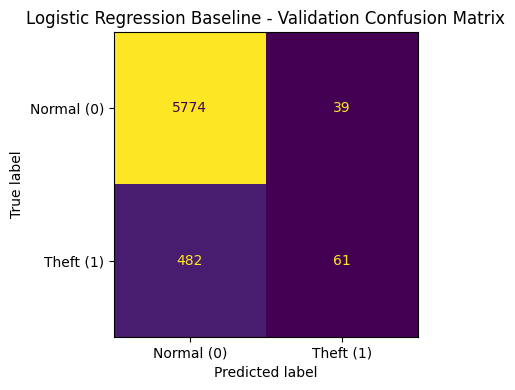

In [9]:
# 9.4. Confusion matrix trên validation set

y_val_pred_baseline = get_predictions_at_threshold(
    y_prob=y_val_prob_baseline, threshold=baseline_threshold
)

baseline_val_cm = plot_confusion_matrix_custom(
    y_true=y_val,
    y_pred=y_val_pred_baseline,
    title="Logistic Regression Baseline - Validation Confusion Matrix",
)

### Nhận Xét:
+ Logistic Regression baseline đạt Accuracy cao trên validation set, nhưng kết quả này chưa phản ánh tốt khả năng phát hiện theft do dữ liệu bị mất cân bằng. Confusion Matrix cho thấy model dự đoán rất tốt class normal với số False Positive thấp, nhưng bỏ sót phần lớn theft customers.

+ Cụ thể, model chỉ phát hiện được 61 trên tổng số 543 theft customers, tương ứng Recall khoảng 11.23%. Điều này cho thấy threshold mặc định 0.5 chưa phù hợp với bài toán Energy Theft Detection, nơi False Negative là lỗi nguy hiểm nhất.

+ Tuy nhiên, ROC-AUC = 0.7946 và PR-AUC = 0.3516 cho thấy model vẫn có khả năng phân biệt nhất định giữa normal và theft. Vì vậy, các bước tiếp theo cần thử Logistic Regression với L2 regularization và thực hiện threshold tuning trên validation set để cải thiện Recall và F1-score.

## 10. Logistic Regression with L2 Regularization

Ở STEP 9, Logistic Regression baseline cho kết quả Recall khá thấp. Điều này cho thấy với threshold mặc định `0.5`, mô hình còn bỏ sót nhiều khách hàng theft.

Trong bước này, ta train **Logistic Regression với L2 regularization**.

**L2 regularization** là kỹ thuật thêm một thành phần phạt vào loss function để hạn chế hệ số của mô hình trở nên quá lớn. Điều này giúp mô hình ổn định hơn và có thể giảm overfitting.

Tham số `C` trong `LogisticRegression` điều khiển mức độ regularization:

- `C` nhỏ => regularization mạnh hơn
- `C` lớn => regularization yếu hơn
- `C = 1.0` là giá trị mặc định thường dùng

Ta chọn `C` dựa trên **validation set**, không dùng test set.  
Validation set được dùng để lựa chọn hyperparameter, còn test set chỉ dùng ở bước đánh giá cuối cùng sau khi model và threshold đã được chọn.

Vì dataset bị mất cân bằng, ta ưu tiên chọn model theo thứ tự:

1. **PR-AUC**: quan trọng khi class theft chiếm tỷ lệ nhỏ.
2. **F1-score**: cân bằng giữa Precision và Recall.
3. **Recall**: đo khả năng phát hiện đúng các khách hàng theft thật.

Ở bước này, ta vẫn giữ threshold mặc định `0.5`.  
Threshold tuning sẽ được thực hiện ở bước sau.

In [10]:
# STEP 10: Logistic Regression with L2 Regularization

from sklearn.linear_model import LogisticRegression

# 10.1. Khai báo grid các giá trị C cần thử

# C càng nhỏ thì regularization càng mạnh.
# C càng lớn thì regularization càng yếu.
C_values = [0.01, 0.1, 1.0, 10.0, 100.0]

l2_result_rows = []
l2_models = {}
l2_val_probabilities = {}

l2_threshold = 0.5


# 10.2. Train và evaluate Logistic Regression L2 cho từng C

for C in C_values:
    model_name = f"Logistic Regression L2 (C={C})"

    logreg_l2 = LogisticRegression(
        penalty="l2", C=C, solver="lbfgs", max_iter=5000, random_state=RANDOM_STATE
    )

    # Train model trên train set.
    logreg_l2.fit(X_train_scaled, y_train)

    # Dự đoán xác suất class 1 = theft trên validation set.
    y_val_prob_l2 = logreg_l2.predict_proba(X_val_scaled)[:, 1]

    # Đánh giá validation set với threshold mặc định 0.5.
    result_row = collect_result_row(
        model_name=model_name,
        split_name="Validation",
        y_true=y_val,
        y_prob=y_val_prob_l2,
        threshold=l2_threshold,
    )

    result_row["C"] = C

    l2_result_rows.append(result_row)
    l2_models[C] = logreg_l2
    l2_val_probabilities[C] = y_val_prob_l2


# 10.3. Tạo bảng so sánh validation metrics cho từng C

l2_results_df = pd.DataFrame(l2_result_rows)

# Sắp xếp theo thứ tự ưu tiên:
# 1. pr_auc giảm dần
# 2. f1_score giảm dần
# 3. recall giảm dần
l2_results_df = l2_results_df.sort_values(
    by=["pr_auc", "f1_score", "recall"], ascending=[False, False, False]
).reset_index(drop=True)

l2_results_df

,model,split,threshold,accuracy,precision,recall,f1_score,roc_auc,pr_auc,C
0,Logistic Regression L2 (C=100.0),Validation,0.5,0.918030,0.610000,0.112339,0.189736,0.794726,0.351561,100.00
1,Logistic Regression L2 (C=10.0),Validation,0.5,0.918030,0.610000,0.112339,0.189736,0.794507,0.350721,10.00
2,Logistic Regression L2 (C=1.0),Validation,0.5,0.918030,0.617021,0.106814,0.182104,0.793735,0.348345,1.00
3,Logistic Regression L2 (C=0.1),Validation,0.5,0.918030,0.641026,0.092081,0.161031,0.793470,0.346926,0.10
4,Logistic Regression L2 (C=0.01),Validation,0.5,0.917873,0.661538,0.079190,0.141447,0.790166,0.339408,0.01


In [11]:
# 10.4. Chọn best C và best L2 model trên validation set

l2_best_row = l2_results_df.iloc[0].to_dict()

logreg_l2_best_C = l2_best_row["C"]
logreg_l2_best = l2_models[logreg_l2_best_C]
y_val_prob_l2_best = l2_val_probabilities[logreg_l2_best_C]

print("Best Logistic Regression L2 model trên validation set")
print(f"Best C       : {logreg_l2_best_C}")
print(f"PR-AUC       : {l2_best_row['pr_auc']:.6f}")
print(f"F1-score     : {l2_best_row['f1_score']:.6f}")
print(f"Recall       : {l2_best_row['recall']:.6f}")
print(f"Precision    : {l2_best_row['precision']:.6f}")
print(f"Accuracy     : {l2_best_row['accuracy']:.6f}")
print(f"ROC-AUC      : {l2_best_row['roc_auc']:.6f}")

Best Logistic Regression L2 model trên validation set
Best C       : 100.0
PR-AUC       : 0.351561
F1-score     : 0.189736
Recall       : 0.112339
Precision    : 0.610000
Accuracy     : 0.918030
ROC-AUC      : 0.794726


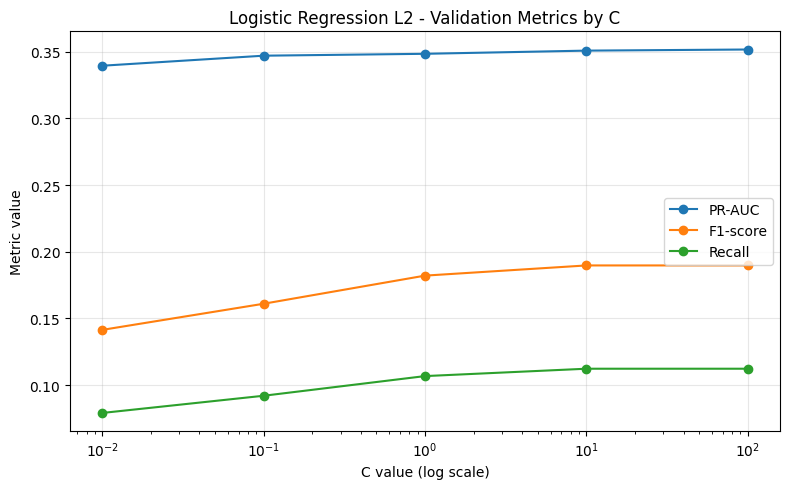

In [12]:
# 10.5. Vẽ biểu đồ PR-AUC, F1-score và Recall theo C

# Để biểu đồ dễ đọc, ta vẽ theo thứ tự C ban đầu thay vì thứ tự đã sort.
l2_plot_df = l2_results_df.sort_values("C").reset_index(drop=True)

plt.figure(figsize=(8, 5))

plt.plot(l2_plot_df["C"], l2_plot_df["pr_auc"], marker="o", label="PR-AUC")

plt.plot(l2_plot_df["C"], l2_plot_df["f1_score"], marker="o", label="F1-score")

plt.plot(l2_plot_df["C"], l2_plot_df["recall"], marker="o", label="Recall")

plt.xscale("log")
plt.xlabel("C value (log scale)")
plt.ylabel("Metric value")
plt.title("Logistic Regression L2 - Validation Metrics by C")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

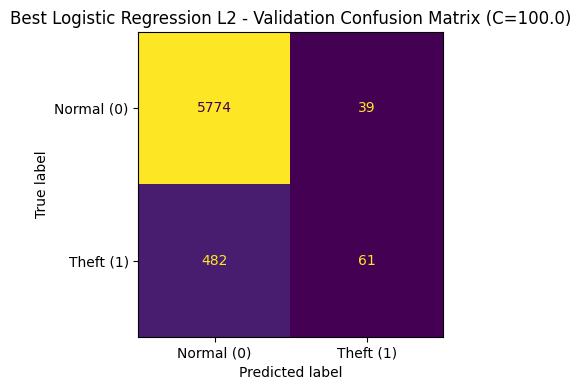

In [13]:
# 10.6. Confusion matrix của best L2 model trên validation set

y_val_pred_l2_best = get_predictions_at_threshold(
    y_prob=y_val_prob_l2_best, threshold=l2_threshold
)

l2_best_val_cm = plot_confusion_matrix_custom(
    y_true=y_val,
    y_pred=y_val_pred_l2_best,
    title=f"Best Logistic Regression L2 - Validation Confusion Matrix (C={logreg_l2_best_C})",
)

### Nhận Xét:
+ Kết quả Logistic Regression với L2 regularization cho thấy model tốt nhất trên validation set đạt được khi C = 100.0. Vì C lớn tương ứng với mức regularization yếu, kết quả này cho thấy regularization mạnh không cải thiện hiệu quả phát hiện theft trong thiết lập hiện tại.

+ So với Logistic Regression baseline, các metric như Accuracy, Precision, Recall và F1-score gần như không thay đổi. ROC-AUC và PR-AUC chỉ tăng rất nhẹ. Confusion Matrix cũng giống baseline, với TP = 61 và FN = 482, cho thấy model vẫn bỏ sót phần lớn khách hàng theft tại threshold mặc định 0.5.

+ Điều này gợi ý rằng vấn đề chính không nằm ở overfitting, mà nằm ở việc threshold mặc định 0.5 chưa phù hợp với dataset mất cân bằng. Do đó, bước tiếp theo cần thực hiện threshold tuning trên validation set để cải thiện Recall và F1-score.

## 11. Threshold Tuning on Validation Set

Ở các bước trước, Logistic Regression baseline và Logistic Regression với L2 đều cho Recall thấp khi dùng threshold mặc định `0.5`. Điều này cho thấy mô hình đang khá “bảo thủ” khi dự đoán class theft.

**Threshold tuning** là quá trình thay đổi ngưỡng phân loại dùng để chuyển xác suất thành nhãn 0/1.

Ví dụ:

- Nếu `threshold = 0.5`, mô hình chỉ dự đoán theft khi xác suất theft >= 0.5.
- Nếu giảm threshold xuống `0.3`, mô hình dễ dự đoán theft hơn.
- Khi đó Recall thường tăng, nhưng Precision có thể giảm.

Với dataset mất cân bằng, threshold mặc định `0.5` thường không tối ưu, đặc biệt khi class theft chiếm tỷ lệ nhỏ. Vì vậy, ta cần thử nhiều threshold khác nhau trên validation set để tìm điểm cân bằng tốt hơn giữa Precision và Recall.

Trong bước này, ta tìm hai loại threshold:

1. **Best F1 threshold**: threshold có F1-score cao nhất, dùng để cân bằng Precision và Recall.
2. **Recall-prioritized threshold**: threshold ưu tiên Recall cao, vì trong bài toán energy theft, bỏ sót khách hàng theft thật là lỗi nghiêm trọng.

Lưu ý quan trọng:

Threshold tuning chỉ được thực hiện trên **validation set**.  
**Test set không được dùng trong bước này** để tránh data leakage. Test set chỉ dùng sau cùng để đánh giá khả năng generalization của model đã chọn.

In [14]:
# STEP 11: Threshold Tuning on Validation Set

# 11.1. Tạo danh sách threshold cần thử

# Thử các threshold từ 0.05 đến 0.95 với bước nhảy 0.01.
# Không dùng threshold quá gần 0 hoặc 1 để tránh các setting quá cực đoan.
thresholds = np.arange(0.05, 0.96, 0.01)

threshold_result_rows = []


# 11.2. Đánh giá best L2 model trên validation set với từng threshold

for threshold in thresholds:
    result_row = collect_result_row(
        model_name=f"Logistic Regression L2 (C={logreg_l2_best_C})",
        split_name="Validation",
        y_true=y_val,
        y_prob=y_val_prob_l2_best,
        threshold=threshold,
    )

    threshold_result_rows.append(result_row)


threshold_results_df = pd.DataFrame(threshold_result_rows)

# Sắp xếp cột để bảng dễ đọc hơn.
threshold_results_df = threshold_results_df[
    [
        "model",
        "split",
        "threshold",
        "accuracy",
        "precision",
        "recall",
        "f1_score",
        "roc_auc",
        "pr_auc",
    ]
]

threshold_results_df.head()

,model,split,threshold,accuracy,precision,recall,f1_score,roc_auc,pr_auc
0,Logistic Regression L2 (C=100.0),Validation,0.05,0.496381,0.132873,0.885820,0.231083,0.794726,0.351561
1,Logistic Regression L2 (C=100.0),Validation,0.06,0.572687,0.148496,0.845304,0.252614,0.794726,0.351561
2,Logistic Regression L2 (C=100.0),Validation,0.07,0.640812,0.165642,0.793738,0.274086,0.794726,0.351561
3,Logistic Regression L2 (C=100.0),Validation,0.08,0.692889,0.181077,0.736648,0.290698,0.794726,0.351561
4,Logistic Regression L2 (C=100.0),Validation,0.09,0.741661,0.204093,0.697974,0.315833,0.794726,0.351561


In [15]:
# 11.3. Tìm Best F1 threshold

# Best F1 threshold là threshold có f1_score cao nhất.
# Nếu có nhiều threshold cùng F1-score, ưu tiên threshold có recall cao hơn.
best_f1_row = (
    threshold_results_df.sort_values(
        by=["f1_score", "recall", "precision"], ascending=[False, False, False]
    )
    .iloc[0]
    .to_dict()
)

best_f1_threshold = best_f1_row["threshold"]

print("Best F1 threshold trên validation set")
print(f"Threshold : {best_f1_threshold:.2f}")
print(f"Precision : {best_f1_row['precision']:.6f}")
print(f"Recall    : {best_f1_row['recall']:.6f}")
print(f"F1-score  : {best_f1_row['f1_score']:.6f}")
print(f"PR-AUC    : {best_f1_row['pr_auc']:.6f}")
print(f"ROC-AUC   : {best_f1_row['roc_auc']:.6f}")

Best F1 threshold trên validation set
Threshold : 0.16
Precision : 0.356105
Recall    : 0.451197
F1-score  : 0.398050
PR-AUC    : 0.351561
ROC-AUC   : 0.794726


In [16]:
# 11.4. Tìm Recall-prioritized threshold

# Chiến lược:
# - Nếu tồn tại threshold có recall >= 0.60:
#     chọn threshold có f1_score cao nhất trong nhóm đó.
# - Nếu không tồn tại:
#     chọn threshold có recall cao nhất, sau đó f1_score cao nhất.
recall_target = 0.60

recall_candidate_df = threshold_results_df[
    threshold_results_df["recall"] >= recall_target
].copy()

if len(recall_candidate_df) > 0:
    recall_priority_row = (
        recall_candidate_df.sort_values(
            by=["f1_score", "precision", "recall"], ascending=[False, False, False]
        )
        .iloc[0]
        .to_dict()
    )

    print(f"Tìm thấy threshold đạt recall >= {recall_target:.2f}.")
    print("Chọn threshold có F1-score cao nhất trong nhóm này.")

else:
    recall_priority_row = (
        threshold_results_df.sort_values(
            by=["recall", "f1_score", "precision"], ascending=[False, False, False]
        )
        .iloc[0]
        .to_dict()
    )

    print(f"Không có threshold nào đạt recall >= {recall_target:.2f}.")
    print("Chọn threshold có Recall cao nhất, sau đó F1-score cao nhất.")


recall_priority_threshold = recall_priority_row["threshold"]

print("\nRecall-prioritized threshold trên validation set")
print(f"Threshold : {recall_priority_threshold:.2f}")
print(f"Precision : {recall_priority_row['precision']:.6f}")
print(f"Recall    : {recall_priority_row['recall']:.6f}")
print(f"F1-score  : {recall_priority_row['f1_score']:.6f}")
print(f"PR-AUC    : {recall_priority_row['pr_auc']:.6f}")
print(f"ROC-AUC   : {recall_priority_row['roc_auc']:.6f}")

Tìm thấy threshold đạt recall >= 0.60.
Chọn threshold có F1-score cao nhất trong nhóm này.

Recall-prioritized threshold trên validation set
Threshold : 0.11
Precision : 0.242826
Recall    : 0.607735
F1-score  : 0.347003
PR-AUC    : 0.351561
ROC-AUC   : 0.794726


In [17]:
# 11.5. Tạo prediction cho hai threshold đã chọn

y_val_pred_l2_best_f1 = get_predictions_at_threshold(
    y_prob=y_val_prob_l2_best, threshold=best_f1_threshold
)

y_val_pred_l2_recall_priority = get_predictions_at_threshold(
    y_prob=y_val_prob_l2_best, threshold=recall_priority_threshold
)

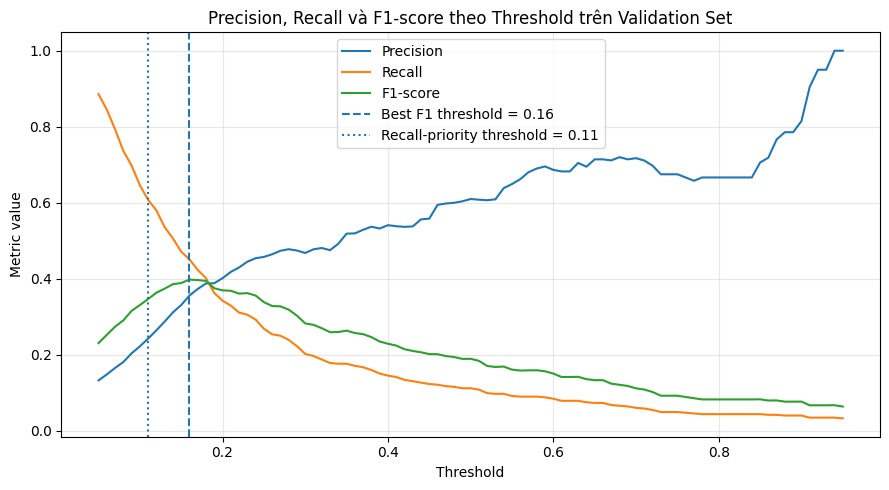

In [18]:
# 11.6. Vẽ Precision, Recall và F1-score theo threshold

plt.figure(figsize=(9, 5))

plt.plot(
    threshold_results_df["threshold"],
    threshold_results_df["precision"],
    label="Precision",
)

plt.plot(
    threshold_results_df["threshold"], threshold_results_df["recall"], label="Recall"
)

plt.plot(
    threshold_results_df["threshold"],
    threshold_results_df["f1_score"],
    label="F1-score",
)

# Đánh dấu best F1 threshold.
plt.axvline(
    best_f1_threshold,
    linestyle="--",
    label=f"Best F1 threshold = {best_f1_threshold:.2f}",
)

# Đánh dấu recall-prioritized threshold.
plt.axvline(
    recall_priority_threshold,
    linestyle=":",
    label=f"Recall-priority threshold = {recall_priority_threshold:.2f}",
)

plt.xlabel("Threshold")
plt.ylabel("Metric value")
plt.title("Precision, Recall và F1-score theo Threshold trên Validation Set")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [19]:
# 11.7. So sánh 3 setting threshold chính

threshold_05_row = collect_result_row(
    model_name=f"Logistic Regression L2 (C={logreg_l2_best_C})",
    split_name="Validation",
    y_true=y_val,
    y_prob=y_val_prob_l2_best,
    threshold=0.5,
)

threshold_comparison_df = pd.DataFrame(
    [
        {"setting": "Default threshold = 0.5", **threshold_05_row},
        {"setting": "Best F1 threshold", **best_f1_row},
        {"setting": "Recall-prioritized threshold", **recall_priority_row},
    ]
)

threshold_comparison_df = threshold_comparison_df[
    [
        "setting",
        "model",
        "split",
        "threshold",
        "accuracy",
        "precision",
        "recall",
        "f1_score",
        "roc_auc",
        "pr_auc",
    ]
]

threshold_comparison_df

,setting,model,split,threshold,accuracy,precision,recall,f1_score,roc_auc,pr_auc
0,Default threshold = 0.5,Logistic Regression L2 (C=100.0),Validation,0.50,0.918030,0.610000,0.112339,0.189736,0.794726,0.351561
1,Best F1 threshold,Logistic Regression L2 (C=100.0),Validation,0.16,0.883417,0.356105,0.451197,0.398050,0.794726,0.351561
2,Recall-prioritized threshold,Logistic Regression L2 (C=100.0),Validation,0.11,0.804594,0.242826,0.607735,0.347003,0.794726,0.351561


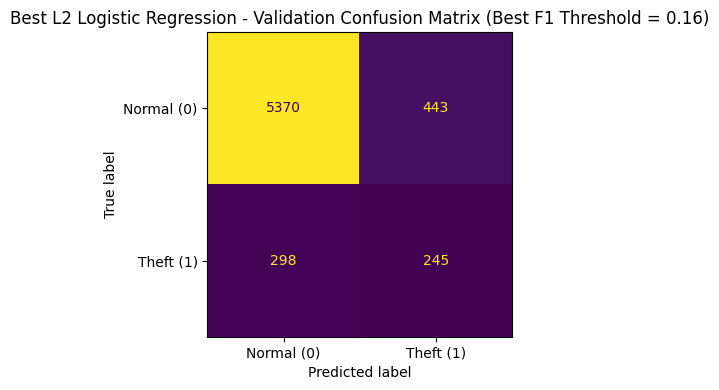

In [20]:
# 11.8. Confusion matrix với Best F1 threshold

best_f1_val_cm = plot_confusion_matrix_custom(
    y_true=y_val,
    y_pred=y_val_pred_l2_best_f1,
    title=(
        "Best L2 Logistic Regression - Validation Confusion Matrix "
        f"(Best F1 Threshold = {best_f1_threshold:.2f})"
    ),
)

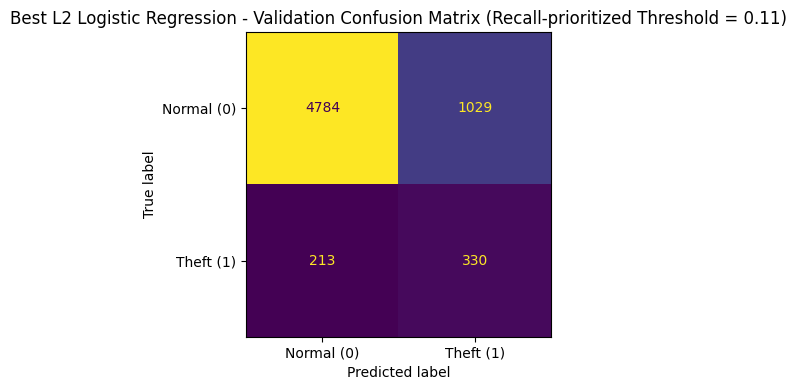

In [21]:
# 11.9. Confusion matrix với Recall-prioritized threshold

recall_priority_val_cm = plot_confusion_matrix_custom(
    y_true=y_val,
    y_pred=y_val_pred_l2_recall_priority,
    title=(
        "Best L2 Logistic Regression - Validation Confusion Matrix "
        f"(Recall-prioritized Threshold = {recall_priority_threshold:.2f})"
    ),
)

### Nhận Xét:
+ Threshold tuning cải thiện rõ rệt khả năng phát hiện theft của Logistic Regression L2. Với threshold mặc định 0.5, model đạt Accuracy cao nhưng Recall chỉ khoảng 11.23%, nghĩa là bỏ sót phần lớn theft customers.

+ Khi giảm threshold xuống 0.16, F1-score đạt giá trị cao nhất trên validation set. Recall tăng từ 11.23% lên 45.12%, trong khi F1-score tăng từ 0.1897 lên 0.3981. Điều này cho thấy threshold mặc định 0.5 không phù hợp với dataset mất cân bằng.

+ Ngoài ra, threshold 0.11 giúp Recall đạt 60.77%, phát hiện được nhiều theft customers hơn, nhưng Precision giảm mạnh và số False Positive tăng đáng kể. Vì vậy, threshold 0.16 được chọn làm threshold chính do cân bằng tốt hơn giữa Precision và Recall, còn threshold 0.11 được dùng để minh họa chiến lược ưu tiên Recall.

## 12. Final Test Evaluation

Ở các bước trước, ta đã chọn:

- Model: **Logistic Regression với L2 regularization**
- Best C: `logreg_l2_best_C`
- Hai threshold từ validation set:
  - **Best F1 threshold**
  - **Recall-prioritized threshold**

Đây là bước đầu tiên sử dụng **test set**.  
Test set chỉ được dùng sau khi model, hyperparameter và threshold đã được chọn xong để tránh data leakage.

Mục tiêu của STEP 12 là đánh giá khả năng **generalization** của model cuối cùng trên dữ liệu chưa từng được dùng trong quá trình train, chọn model hoặc tune threshold.

Ta evaluate test set với 3 threshold:

1. **Default threshold = 0.5**  
   Dùng làm mốc so sánh với threshold mặc định.

2. **Best F1 threshold**  
   Dùng khi muốn cân bằng Precision và Recall.

3. **Recall-prioritized threshold**  
   Dùng khi muốn ưu tiên phát hiện nhiều theft customer hơn, tức giảm False Negative.

Cách đọc kết quả:

- Nếu validation và test có metric gần nhau, model có khả năng generalization tương đối ổn.
- Nếu test kém hơn validation nhiều, có thể model hoặc threshold đang bị overfit theo validation set.
- Nếu Recall tăng nhưng Precision giảm, đó là precision-recall tradeoff bình thường khi hạ threshold.
- Trong bài toán energy theft, cần đặc biệt chú ý Recall và số lượng False Negative.

In [22]:
# STEP 12: Final Test Evaluation

# 12.1. Predict probability trên test set

# Đây là lần đầu tiên test set được sử dụng.
# Không train thêm model, không chọn lại C, không tune thêm threshold trên test set.
# Ta chỉ dùng model L2 tốt nhất đã chọn từ validation set để đánh giá cuối cùng.
y_test_prob_l2_best = logreg_l2_best.predict_proba(X_test_scaled)[:, 1]

In [23]:
# 12.2. Evaluate test set với 3 threshold

test_default_row = collect_result_row(
    model_name=f"Logistic Regression L2 (C={logreg_l2_best_C})",
    split_name="Test",
    y_true=y_test,
    y_prob=y_test_prob_l2_best,
    threshold=0.5,
)

test_best_f1_row = collect_result_row(
    model_name=f"Logistic Regression L2 (C={logreg_l2_best_C})",
    split_name="Test",
    y_true=y_test,
    y_prob=y_test_prob_l2_best,
    threshold=best_f1_threshold,
)

test_recall_priority_row = collect_result_row(
    model_name=f"Logistic Regression L2 (C={logreg_l2_best_C})",
    split_name="Test",
    y_true=y_test,
    y_prob=y_test_prob_l2_best,
    threshold=recall_priority_threshold,
)

test_results_df = pd.DataFrame(
    [
        {"setting": "Default threshold = 0.5", **test_default_row},
        {"setting": "Best F1 threshold", **test_best_f1_row},
        {"setting": "Recall-prioritized threshold", **test_recall_priority_row},
    ]
)

test_results_df = test_results_df[
    [
        "setting",
        "model",
        "split",
        "threshold",
        "accuracy",
        "precision",
        "recall",
        "f1_score",
        "roc_auc",
        "pr_auc",
    ]
]

test_results_df

,setting,model,split,threshold,accuracy,precision,recall,f1_score,roc_auc,pr_auc
0,Default threshold = 0.5,Logistic Regression L2 (C=100.0),Test,0.50,0.915985,0.542553,0.094096,0.160377,0.773105,0.311792
1,Best F1 threshold,Logistic Regression L2 (C=100.0),Test,0.16,0.871145,0.303546,0.394834,0.343224,0.773105,0.311792
2,Recall-prioritized threshold,Logistic Regression L2 (C=100.0),Test,0.11,0.797514,0.224686,0.560886,0.320844,0.773105,0.311792


In [24]:
# 12.3. Tạo prediction variables trên test set cho các bước sau

y_test_pred_l2_best_f1 = get_predictions_at_threshold(
    y_prob=y_test_prob_l2_best, threshold=best_f1_threshold
)

y_test_pred_l2_recall_priority = get_predictions_at_threshold(
    y_prob=y_test_prob_l2_best, threshold=recall_priority_threshold
)

In [25]:
# 12.4. So sánh validation vs test cho hai threshold đã chọn

# Lưu ý:
# best_f1_row và recall_priority_row là kết quả trên validation set từ STEP 11.
# test_best_f1_row và test_recall_priority_row là kết quả trên test set ở STEP 12.
final_validation_test_comparison_df = pd.DataFrame(
    [
        {"setting": "Best F1 threshold", **best_f1_row},
        {"setting": "Best F1 threshold", **test_best_f1_row},
        {"setting": "Recall-prioritized threshold", **recall_priority_row},
        {"setting": "Recall-prioritized threshold", **test_recall_priority_row},
    ]
)

final_validation_test_comparison_df = final_validation_test_comparison_df[
    [
        "setting",
        "model",
        "split",
        "threshold",
        "accuracy",
        "precision",
        "recall",
        "f1_score",
        "roc_auc",
        "pr_auc",
    ]
]

final_validation_test_comparison_df

,setting,model,split,threshold,accuracy,precision,recall,f1_score,roc_auc,pr_auc
0,Best F1 threshold,Logistic Regression L2 (C=100.0),Validation,0.16,0.883417,0.356105,0.451197,0.398050,0.794726,0.351561
1,Best F1 threshold,Logistic Regression L2 (C=100.0),Test,0.16,0.871145,0.303546,0.394834,0.343224,0.773105,0.311792
2,Recall-prioritized threshold,Logistic Regression L2 (C=100.0),Validation,0.11,0.804594,0.242826,0.607735,0.347003,0.794726,0.351561
3,Recall-prioritized threshold,Logistic Regression L2 (C=100.0),Test,0.11,0.797514,0.224686,0.560886,0.320844,0.773105,0.311792


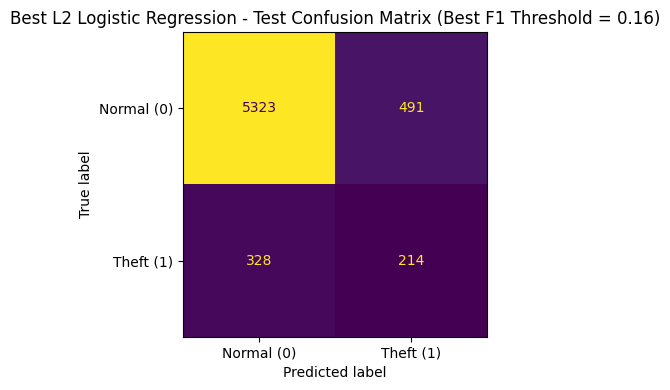

In [26]:
# 12.5. Confusion matrix trên test set với Best F1 threshold

test_best_f1_cm = plot_confusion_matrix_custom(
    y_true=y_test,
    y_pred=y_test_pred_l2_best_f1,
    title=(
        "Best L2 Logistic Regression - Test Confusion Matrix "
        f"(Best F1 Threshold = {best_f1_threshold:.2f})"
    ),
)

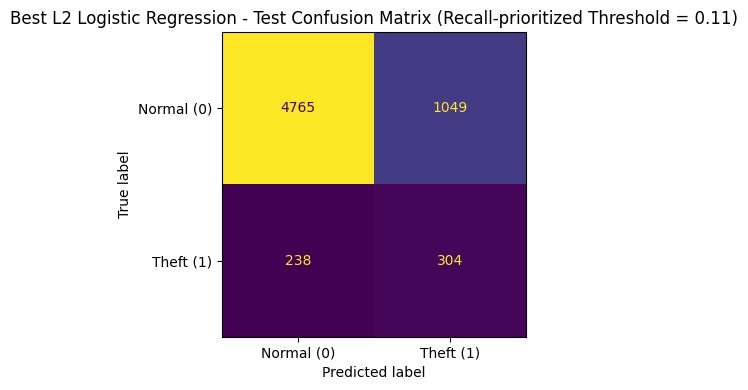

In [27]:
# 12.6. Confusion matrix trên test set với Recall-prioritized threshold

test_recall_priority_cm = plot_confusion_matrix_custom(
    y_true=y_test,
    y_pred=y_test_pred_l2_recall_priority,
    title=(
        "Best L2 Logistic Regression - Test Confusion Matrix "
        f"(Recall-prioritized Threshold = {recall_priority_threshold:.2f})"
    ),
)

### Nhận Xét:
+ Trên test set, Logistic Regression L2 với threshold mặc định 0.5 vẫn đạt Accuracy cao nhưng Recall rất thấp, chỉ khoảng 9.41%. Điều này tiếp tục cho thấy threshold mặc định không phù hợp với bài toán dữ liệu mất cân bằng.

+ Khi sử dụng Best F1 threshold = 0.16 được chọn từ validation set, Recall trên test tăng lên 39.48% và F1-score đạt 0.3432. Mặc dù Precision giảm so với threshold 0.5, model phát hiện được nhiều theft customers hơn đáng kể.

+ Với Recall-prioritized threshold = 0.11, Recall trên test tăng lên 56.09%, nhưng Precision giảm còn 0.2247 và số False Positive tăng mạnh. Do đó, threshold 0.11 phù hợp nếu mục tiêu là giảm False Negative, trong khi threshold 0.16 là lựa chọn cân bằng hơn giữa Precision và Recall.

+ So sánh validation và test cho thấy các metric giảm không quá lớn, đặc biệt với hai threshold đã chọn. Điều này cho thấy model Logistic Regression L2 có khả năng generalization tương đối ổn trên dữ liệu chưa thấy.

## 13. Gaussian Discriminant Analysis

Trong bước này, ta train **Gaussian Discriminant Analysis (GDA)** để làm model so sánh với Logistic Regression.

GDA thuộc nhóm **generative learning**. Thay vì học trực tiếp xác suất \(P(y|x)\), GDA mô hình hóa phân phối dữ liệu theo từng class, tức học:

- \(P(x|y=0)\): phân phối feature của normal customer
- \(P(x|y=1)\): phân phối feature của theft customer
- \(P(y)\): xác suất prior của từng class

Sau đó, model dùng Bayes rule để suy ra xác suất một customer thuộc class theft.

Khác biệt chính:

- **Logistic Regression** là discriminative model, học trực tiếp ranh giới phân loại hoặc xác suất \(P(y|x)\).
- **GDA** là generative model, học cách dữ liệu được sinh ra trong từng class thông qua giả định phân phối Gaussian.

Trong project này, GDA được dùng làm model so sánh để làm rõ sự khác biệt giữa **generative learning** và **discriminative learning**.

Ta ưu tiên dùng `LinearDiscriminantAnalysis` thay vì `QuadraticDiscriminantAnalysis` vì dataset hiện tại có nhiều feature. LDA giả định hai class có covariance matrix giống nhau, nên thường ổn định hơn QDA khi số feature lớn hoặc covariance matrix khó ước lượng chính xác.

Tương tự Logistic Regression, threshold mặc định `0.5` có thể không tối ưu với dữ liệu mất cân bằng. Vì vậy, ta tune threshold trên **validation set**.

Lưu ý quan trọng:

- Validation set được dùng để chọn threshold.
- Test set chỉ dùng để đánh giá cuối cùng.
- Không dùng test set để chọn threshold hoặc chọn model.

In [28]:
# STEP 13: Gaussian Discriminant Analysis

from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
import warnings

# 13.1. Train Gaussian Discriminant Analysis bằng LDA

# Ta dùng LinearDiscriminantAnalysis như một dạng GDA ổn định hơn cho dữ liệu nhiều feature.
# LDA giả định các class có chung covariance matrix.
# Solver "lsqr" kết hợp shrinkage="auto" giúp tăng ổn định số học khi feature có tương quan cao.
gda_model = LinearDiscriminantAnalysis(solver="lsqr", shrinkage="auto")

# Một số dataset có thể tạo cảnh báo numerical stability do covariance matrix.
# Ở đây ta dùng shrinkage="auto" để giảm rủi ro đó.
with warnings.catch_warnings():
    warnings.simplefilter("always")
    gda_model.fit(X_train_scaled, y_train)


# 13.2. Predict probability trên validation set và test set

# predict_proba trả về [P(class 0), P(class 1)].
# Ta lấy cột class 1 vì class 1 = theft.
y_val_prob_gda = gda_model.predict_proba(X_val_scaled)[:, 1]
y_test_prob_gda = gda_model.predict_proba(X_test_scaled)[:, 1]

In [29]:
# 13.3. Evaluate GDA trên validation set với threshold mặc định 0.5

gda_val_default_row = collect_result_row(
    model_name="Gaussian Discriminant Analysis - LDA",
    split_name="Validation",
    y_true=y_val,
    y_prob=y_val_prob_gda,
    threshold=0.5,
)

gda_val_default_df = pd.DataFrame([gda_val_default_row])

gda_val_default_df

,model,split,threshold,accuracy,precision,recall,f1_score,roc_auc,pr_auc
0,Gaussian Discriminant Analysis - LDA,Validation,0.5,0.915198,0.512987,0.145488,0.226686,0.792571,0.335403


In [30]:
# 13.4. Threshold tuning cho GDA trên validation set

gda_thresholds = np.arange(0.05, 0.96, 0.01)

gda_threshold_result_rows = []

for threshold in gda_thresholds:
    result_row = collect_result_row(
        model_name="Gaussian Discriminant Analysis - LDA",
        split_name="Validation",
        y_true=y_val,
        y_prob=y_val_prob_gda,
        threshold=threshold,
    )

    gda_threshold_result_rows.append(result_row)


gda_threshold_results_df = pd.DataFrame(gda_threshold_result_rows)

gda_threshold_results_df = gda_threshold_results_df[
    [
        "model",
        "split",
        "threshold",
        "accuracy",
        "precision",
        "recall",
        "f1_score",
        "roc_auc",
        "pr_auc",
    ]
]

gda_threshold_results_df.head()

,model,split,threshold,accuracy,precision,recall,f1_score,roc_auc,pr_auc
0,Gaussian Discriminant Analysis - LDA,Validation,0.05,0.675267,0.177070,0.767956,0.287785,0.792571,0.335403
1,Gaussian Discriminant Analysis - LDA,Validation,0.06,0.736784,0.198506,0.685083,0.307820,0.792571,0.335403
2,Gaussian Discriminant Analysis - LDA,Validation,0.07,0.778477,0.222579,0.639042,0.330162,0.792571,0.335403
3,Gaussian Discriminant Analysis - LDA,Validation,0.08,0.808685,0.245654,0.598527,0.348339,0.792571,0.335403
4,Gaussian Discriminant Analysis - LDA,Validation,0.09,0.827722,0.259162,0.546961,0.351687,0.792571,0.335403


In [31]:
# 13.5. Tìm Best F1 threshold cho GDA

# Nếu nhiều threshold có cùng F1-score, ưu tiên recall cao hơn,
# sau đó precision cao hơn.
gda_best_f1_row = (
    gda_threshold_results_df.sort_values(
        by=["f1_score", "recall", "precision"], ascending=[False, False, False]
    )
    .iloc[0]
    .to_dict()
)

gda_best_f1_threshold = gda_best_f1_row["threshold"]

print("GDA - Best F1 threshold trên validation set")
print(f"Threshold : {gda_best_f1_threshold:.2f}")
print(f"Precision : {gda_best_f1_row['precision']:.6f}")
print(f"Recall    : {gda_best_f1_row['recall']:.6f}")
print(f"F1-score  : {gda_best_f1_row['f1_score']:.6f}")
print(f"PR-AUC    : {gda_best_f1_row['pr_auc']:.6f}")
print(f"ROC-AUC   : {gda_best_f1_row['roc_auc']:.6f}")

GDA - Best F1 threshold trên validation set
Threshold : 0.14
Precision : 0.356822
Recall    : 0.438306
F1-score  : 0.393388
PR-AUC    : 0.335403
ROC-AUC   : 0.792571


In [32]:
# 13.6. Tìm Recall-prioritized threshold cho GDA

# Chiến lược giống STEP 11:
# - Nếu tồn tại threshold có recall >= 0.60:
#     chọn threshold có f1_score cao nhất trong nhóm đó.
# - Nếu không tồn tại:
#     chọn threshold có recall cao nhất, sau đó f1_score cao nhất.
gda_recall_target = 0.60

gda_recall_candidate_df = gda_threshold_results_df[
    gda_threshold_results_df["recall"] >= gda_recall_target
].copy()

if len(gda_recall_candidate_df) > 0:
    gda_recall_priority_row = (
        gda_recall_candidate_df.sort_values(
            by=["f1_score", "precision", "recall"], ascending=[False, False, False]
        )
        .iloc[0]
        .to_dict()
    )

    print(f"Tìm thấy threshold GDA đạt recall >= {gda_recall_target:.2f}.")
    print("Chọn threshold có F1-score cao nhất trong nhóm này.")

else:
    gda_recall_priority_row = (
        gda_threshold_results_df.sort_values(
            by=["recall", "f1_score", "precision"], ascending=[False, False, False]
        )
        .iloc[0]
        .to_dict()
    )

    print(f"Không có threshold GDA nào đạt recall >= {gda_recall_target:.2f}.")
    print("Chọn threshold có Recall cao nhất, sau đó F1-score cao nhất.")


gda_recall_priority_threshold = gda_recall_priority_row["threshold"]

print("\nGDA - Recall-prioritized threshold trên validation set")
print(f"Threshold : {gda_recall_priority_threshold:.2f}")
print(f"Precision : {gda_recall_priority_row['precision']:.6f}")
print(f"Recall    : {gda_recall_priority_row['recall']:.6f}")
print(f"F1-score  : {gda_recall_priority_row['f1_score']:.6f}")
print(f"PR-AUC    : {gda_recall_priority_row['pr_auc']:.6f}")
print(f"ROC-AUC   : {gda_recall_priority_row['roc_auc']:.6f}")

Tìm thấy threshold GDA đạt recall >= 0.60.
Chọn threshold có F1-score cao nhất trong nhóm này.

GDA - Recall-prioritized threshold trên validation set
Threshold : 0.07
Precision : 0.222579
Recall    : 0.639042
F1-score  : 0.330162
PR-AUC    : 0.335403
ROC-AUC   : 0.792571


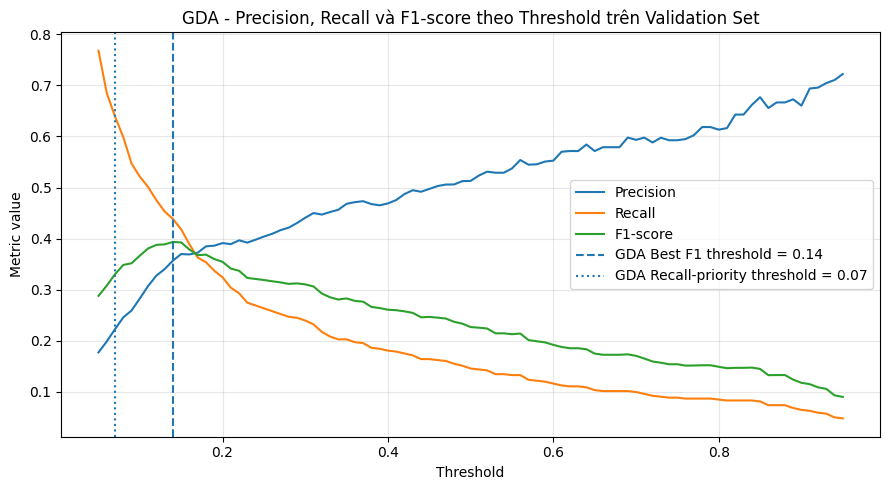

In [33]:
# 13.7. Vẽ Precision, Recall và F1-score theo threshold của GDA

plt.figure(figsize=(9, 5))

plt.plot(
    gda_threshold_results_df["threshold"],
    gda_threshold_results_df["precision"],
    label="Precision",
)

plt.plot(
    gda_threshold_results_df["threshold"],
    gda_threshold_results_df["recall"],
    label="Recall",
)

plt.plot(
    gda_threshold_results_df["threshold"],
    gda_threshold_results_df["f1_score"],
    label="F1-score",
)

plt.axvline(
    gda_best_f1_threshold,
    linestyle="--",
    label=f"GDA Best F1 threshold = {gda_best_f1_threshold:.2f}",
)

plt.axvline(
    gda_recall_priority_threshold,
    linestyle=":",
    label=f"GDA Recall-priority threshold = {gda_recall_priority_threshold:.2f}",
)

plt.xlabel("Threshold")
plt.ylabel("Metric value")
plt.title("GDA - Precision, Recall và F1-score theo Threshold trên Validation Set")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [34]:
# 13.8. Evaluate GDA trên test set với 3 threshold

# Không tune threshold trên test set.
# Ba threshold dưới đây đã được xác định trước:
# - 0.5 là threshold mặc định
# - gda_best_f1_threshold chọn từ validation set
# - gda_recall_priority_threshold chọn từ validation set
gda_test_default_row = collect_result_row(
    model_name="Gaussian Discriminant Analysis - LDA",
    split_name="Test",
    y_true=y_test,
    y_prob=y_test_prob_gda,
    threshold=0.5,
)

gda_test_best_f1_row = collect_result_row(
    model_name="Gaussian Discriminant Analysis - LDA",
    split_name="Test",
    y_true=y_test,
    y_prob=y_test_prob_gda,
    threshold=gda_best_f1_threshold,
)

gda_test_recall_priority_row = collect_result_row(
    model_name="Gaussian Discriminant Analysis - LDA",
    split_name="Test",
    y_true=y_test,
    y_prob=y_test_prob_gda,
    threshold=gda_recall_priority_threshold,
)

gda_test_results_df = pd.DataFrame(
    [
        {"setting": "GDA default threshold = 0.5", **gda_test_default_row},
        {"setting": "GDA Best F1 threshold", **gda_test_best_f1_row},
        {"setting": "GDA Recall-prioritized threshold", **gda_test_recall_priority_row},
    ]
)

gda_test_results_df = gda_test_results_df[
    [
        "setting",
        "model",
        "split",
        "threshold",
        "accuracy",
        "precision",
        "recall",
        "f1_score",
        "roc_auc",
        "pr_auc",
    ]
]

gda_test_results_df

,setting,model,split,threshold,accuracy,precision,recall,f1_score,roc_auc,pr_auc
0,GDA default threshold = 0.5,Gaussian Discriminant Analysis - LDA,Test,0.50,0.915828,0.524138,0.140221,0.221252,0.772393,0.308164
1,GDA Best F1 threshold,Gaussian Discriminant Analysis - LDA,Test,0.14,0.872089,0.299259,0.372694,0.331964,0.772393,0.308164
2,GDA Recall-prioritized threshold,Gaussian Discriminant Analysis - LDA,Test,0.07,0.768880,0.203455,0.586716,0.302138,0.772393,0.308164


In [35]:
# 13.9. Tạo prediction variables cho GDA trên test set

y_test_pred_gda_best_f1 = get_predictions_at_threshold(
    y_prob=y_test_prob_gda, threshold=gda_best_f1_threshold
)

y_test_pred_gda_recall_priority = get_predictions_at_threshold(
    y_prob=y_test_prob_gda, threshold=gda_recall_priority_threshold
)

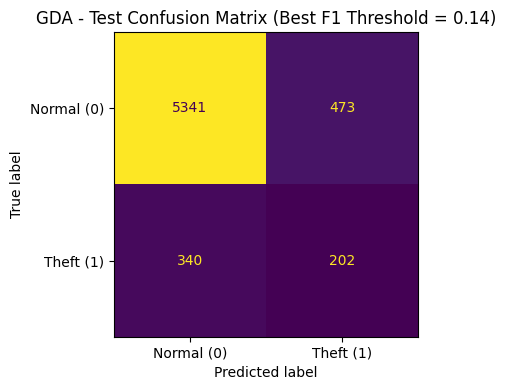

In [36]:
# 13.10. Confusion matrix trên test set với GDA Best F1 threshold

gda_test_best_f1_cm = plot_confusion_matrix_custom(
    y_true=y_test,
    y_pred=y_test_pred_gda_best_f1,
    title=(
        "GDA - Test Confusion Matrix "
        f"(Best F1 Threshold = {gda_best_f1_threshold:.2f})"
    ),
)

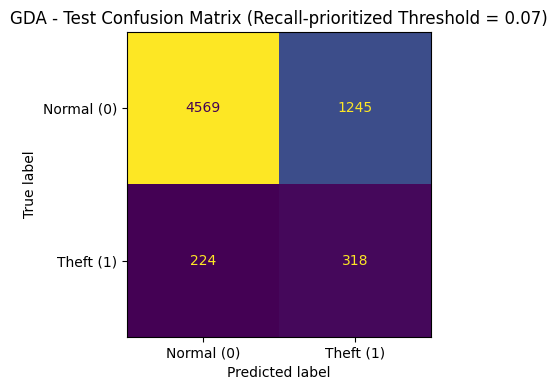

In [37]:
# 13.11. Confusion matrix trên test set với GDA Recall-prioritized threshold

gda_test_recall_priority_cm = plot_confusion_matrix_custom(
    y_true=y_test,
    y_pred=y_test_pred_gda_recall_priority,
    title=(
        "GDA - Test Confusion Matrix "
        f"(Recall-prioritized Threshold = {gda_recall_priority_threshold:.2f})"
    ),
)

In [38]:
# 13.12. So sánh ngắn Logistic Regression L2 và GDA trên test set

"""
Các biến test_best_f1_row và test_recall_priority_row đã được tạo ở STEP 12
cho Logistic Regression L2 final model.
"""

model_comparison_test_df = pd.DataFrame(
    [
        {
            "comparison_setting": "Logistic Regression L2 - Best F1 threshold",
            **test_best_f1_row,
        },
        {"comparison_setting": "GDA - Best F1 threshold", **gda_test_best_f1_row},
        {
            "comparison_setting": "Logistic Regression L2 - Recall-prioritized threshold",
            **test_recall_priority_row,
        },
        {
            "comparison_setting": "GDA - Recall-prioritized threshold",
            **gda_test_recall_priority_row,
        },
    ]
)

model_comparison_test_df = model_comparison_test_df[
    [
        "comparison_setting",
        "model",
        "split",
        "threshold",
        "accuracy",
        "precision",
        "recall",
        "f1_score",
        "roc_auc",
        "pr_auc",
    ]
]

model_comparison_test_df

,comparison_setting,model,split,threshold,accuracy,precision,recall,f1_score,roc_auc,pr_auc
0,Logistic Regression L2 - Best F1 threshold,Logistic Regression L2 (C=100.0),Test,0.16,0.871145,0.303546,0.394834,0.343224,0.773105,0.311792
1,GDA - Best F1 threshold,Gaussian Discriminant Analysis - LDA,Test,0.14,0.872089,0.299259,0.372694,0.331964,0.772393,0.308164
2,Logistic Regression L2 - Recall-prioritized th...,Logistic Regression L2 (C=100.0),Test,0.11,0.797514,0.224686,0.560886,0.320844,0.773105,0.311792
3,GDA - Recall-prioritized threshold,Gaussian Discriminant Analysis - LDA,Test,0.07,0.768880,0.203455,0.586716,0.302138,0.772393,0.308164


### Nhận Xét:
+ Kết quả so sánh cho thấy Gaussian Discriminant Analysis thông qua Linear Discriminant Analysis đạt hiệu năng khá gần Logistic Regression L2, nhưng nhìn chung vẫn kém hơn nhẹ ở các metric quan trọng như F1-score, ROC-AUC và PR-AUC.

+ Ở Best F1 threshold, Logistic Regression L2 đạt F1-score cao hơn GDA và phát hiện được nhiều theft customers hơn, dù GDA có số False Positive thấp hơn một chút. Ở Recall-prioritized threshold, GDA đạt Recall cao hơn, nhưng phải đánh đổi bằng số False Positive lớn hơn đáng kể, làm Precision và F1-score thấp hơn Logistic Regression L2.

+ Điều này cho thấy GDA có thể phát hiện thêm một số theft cases khi giảm threshold mạnh, nhưng Logistic Regression L2 tạo ra trade-off cân bằng và ổn định hơn. Kết quả này cũng phù hợp về mặt lý thuyết vì Logistic Regression là discriminative model, học trực tiếp xác suất P(y|x), trong khi GDA dựa trên giả định phân phối Gaussian của feature theo từng class. Với các feature hành vi tiêu thụ điện phức tạp, giả định Gaussian có thể không phù hợp hoàn toàn.

+ Do đó, Logistic Regression L2 vẫn được giữ làm model chính, còn GDA đóng vai trò model so sánh để minh họa sự khác biệt giữa generative learning và discriminative learning.

## 14. Linear Regression Baseline

Trong bước này, ta dùng **Linear Regression** như một baseline phụ để so sánh với các model classification.

Linear Regression là mô hình dành cho **regression**, tức dự đoán giá trị liên tục.  
Trong khi đó, bài toán của project là **binary classification**:

- `0 = normal customer`
- `1 = theft customer`

Vì vậy, Linear Regression không phải là lựa chọn tự nhiên cho bài toán này.

Lý do Linear Regression không phù hợp bằng Logistic Regression:

1. **Output không bị giới hạn trong [0, 1]**  
   Linear Regression có thể dự đoán giá trị nhỏ hơn 0 hoặc lớn hơn 1, nên output không phải xác suất hợp lệ.

2. **Không tối ưu trực tiếp cho classification**  
   Linear Regression tối ưu Mean Squared Error, trong khi Logistic Regression tối ưu loss phù hợp hơn cho phân loại nhị phân.

3. **Không có sigmoid để ánh xạ sang xác suất**  
   Logistic Regression dùng sigmoid để chuyển linear score thành xác suất thuộc class 1. Vì vậy, output của Logistic Regression có ý nghĩa xác suất rõ ràng hơn.

Trong bước này, để có thể so sánh Linear Regression với các model classification, ta xử lý output theo hướng an toàn:

- Dự đoán raw score trên validation và test set.
- Clip raw score về khoảng `[0, 1]`.
- Xem score sau khi clip như một probability-like score.
- Tune threshold trên validation set giống các bước trước.

Linear Regression chỉ được dùng để chứng minh **model suitability**, không được xem là model chính hay model cuối cùng.

Nếu Linear Regression có ROC-AUC hoặc PR-AUC chấp nhận được, điều đó chỉ cho thấy raw score có khả năng ranking nhất định. Tuy nhiên, điều này không làm Linear Regression phù hợp hơn Logistic Regression cho binary classification.

In [39]:
# STEP 14: Linear Regression Baseline

from sklearn.linear_model import LinearRegression

# 14.1. Train Linear Regression baseline

# Linear Regression không phải classification model.
# Ta chỉ dùng nó như baseline phụ để so sánh model suitability.
linear_reg_model = LinearRegression()

linear_reg_model.fit(X_train_scaled, y_train)


# 14.2. Predict raw scores trên validation set và test set

# Output của Linear Regression là giá trị liên tục.
# Giá trị này có thể nhỏ hơn 0 hoặc lớn hơn 1, nên không phải xác suất hợp lệ.
y_val_score_linear_raw = linear_reg_model.predict(X_val_scaled)
y_test_score_linear_raw = linear_reg_model.predict(X_test_scaled)


# 14.3. Clip raw scores về [0, 1] để dùng như probability-like scores

# Việc clip giúp các score nằm trong khoảng giống xác suất.
# Tuy nhiên, cần nhớ rằng đây không phải xác suất thật như Logistic Regression.
y_val_prob_linear = np.clip(y_val_score_linear_raw, 0, 1)
y_test_prob_linear = np.clip(y_test_score_linear_raw, 0, 1)

In [40]:
# 14.4. Evaluate Linear Regression baseline trên validation set với threshold = 0.5

linear_val_default_row = collect_result_row(
    model_name="Linear Regression Baseline",
    split_name="Validation",
    y_true=y_val,
    y_prob=y_val_prob_linear,
    threshold=0.5,
)

linear_val_default_df = pd.DataFrame([linear_val_default_row])

linear_val_default_df

,model,split,threshold,accuracy,precision,recall,f1_score,roc_auc,pr_auc
0,Linear Regression Baseline,Validation,0.5,0.917244,0.666667,0.062615,0.114478,0.791004,0.342489


In [41]:
# 14.5. Threshold tuning cho Linear Regression trên validation set

linear_thresholds = np.arange(0.05, 0.96, 0.01)

linear_threshold_result_rows = []

for threshold in linear_thresholds:
    result_row = collect_result_row(
        model_name="Linear Regression Baseline",
        split_name="Validation",
        y_true=y_val,
        y_prob=y_val_prob_linear,
        threshold=threshold,
    )

    linear_threshold_result_rows.append(result_row)


linear_threshold_results_df = pd.DataFrame(linear_threshold_result_rows)

linear_threshold_results_df = linear_threshold_results_df[
    [
        "model",
        "split",
        "threshold",
        "accuracy",
        "precision",
        "recall",
        "f1_score",
        "roc_auc",
        "pr_auc",
    ]
]

linear_threshold_results_df.head()

,model,split,threshold,accuracy,precision,recall,f1_score,roc_auc,pr_auc
0,Linear Regression Baseline,Validation,0.05,0.450283,0.125032,0.906077,0.219741,0.791004,0.342489
1,Linear Regression Baseline,Validation,0.06,0.506608,0.135302,0.885820,0.234749,0.791004,0.342489
2,Linear Regression Baseline,Validation,0.07,0.568125,0.146662,0.841621,0.249795,0.791004,0.342489
3,Linear Regression Baseline,Validation,0.08,0.623505,0.159426,0.797422,0.265726,0.791004,0.342489
4,Linear Regression Baseline,Validation,0.09,0.679043,0.176674,0.753223,0.286214,0.791004,0.342489


In [42]:
# 14.6. Tìm Best F1 threshold cho Linear Regression

# Nếu nhiều threshold có cùng F1-score, ưu tiên recall cao hơn,
# sau đó precision cao hơn.
linear_best_f1_row = (
    linear_threshold_results_df.sort_values(
        by=["f1_score", "recall", "precision"], ascending=[False, False, False]
    )
    .iloc[0]
    .to_dict()
)

linear_best_f1_threshold = linear_best_f1_row["threshold"]

print("Linear Regression - Best F1 threshold trên validation set")
print(f"Threshold : {linear_best_f1_threshold:.2f}")
print(f"Precision : {linear_best_f1_row['precision']:.6f}")
print(f"Recall    : {linear_best_f1_row['recall']:.6f}")
print(f"F1-score  : {linear_best_f1_row['f1_score']:.6f}")
print(f"PR-AUC    : {linear_best_f1_row['pr_auc']:.6f}")
print(f"ROC-AUC   : {linear_best_f1_row['roc_auc']:.6f}")

Linear Regression - Best F1 threshold trên validation set
Threshold : 0.17
Precision : 0.350211
Recall    : 0.458564
F1-score  : 0.397129
PR-AUC    : 0.342489
ROC-AUC   : 0.791004


In [43]:
# 14.7. Tìm Recall-prioritized threshold cho Linear Regression

# Chiến lược giống STEP 11 và STEP 13:
# - Nếu tồn tại threshold có recall >= 0.60:
#     chọn threshold có f1_score cao nhất trong nhóm đó.
# - Nếu không tồn tại:
#     chọn threshold có recall cao nhất, sau đó f1_score cao nhất.
linear_recall_target = 0.60

linear_recall_candidate_df = linear_threshold_results_df[
    linear_threshold_results_df["recall"] >= linear_recall_target
].copy()

if len(linear_recall_candidate_df) > 0:
    linear_recall_priority_row = (
        linear_recall_candidate_df.sort_values(
            by=["f1_score", "precision", "recall"], ascending=[False, False, False]
        )
        .iloc[0]
        .to_dict()
    )

    print(
        f"Tìm thấy threshold Linear Regression đạt recall >= {linear_recall_target:.2f}."
    )
    print("Chọn threshold có F1-score cao nhất trong nhóm này.")

else:
    linear_recall_priority_row = (
        linear_threshold_results_df.sort_values(
            by=["recall", "f1_score", "precision"], ascending=[False, False, False]
        )
        .iloc[0]
        .to_dict()
    )

    print(
        f"Không có threshold Linear Regression nào đạt recall >= {linear_recall_target:.2f}."
    )
    print("Chọn threshold có Recall cao nhất, sau đó F1-score cao nhất.")


linear_recall_priority_threshold = linear_recall_priority_row["threshold"]

print("\nLinear Regression - Recall-prioritized threshold trên validation set")
print(f"Threshold : {linear_recall_priority_threshold:.2f}")
print(f"Precision : {linear_recall_priority_row['precision']:.6f}")
print(f"Recall    : {linear_recall_priority_row['recall']:.6f}")
print(f"F1-score  : {linear_recall_priority_row['f1_score']:.6f}")
print(f"PR-AUC    : {linear_recall_priority_row['pr_auc']:.6f}")
print(f"ROC-AUC   : {linear_recall_priority_row['roc_auc']:.6f}")

Tìm thấy threshold Linear Regression đạt recall >= 0.60.
Chọn threshold có F1-score cao nhất trong nhóm này.

Linear Regression - Recall-prioritized threshold trên validation set
Threshold : 0.12
Precision : 0.230094
Recall    : 0.627993
F1-score  : 0.336790
PR-AUC    : 0.342489
ROC-AUC   : 0.791004


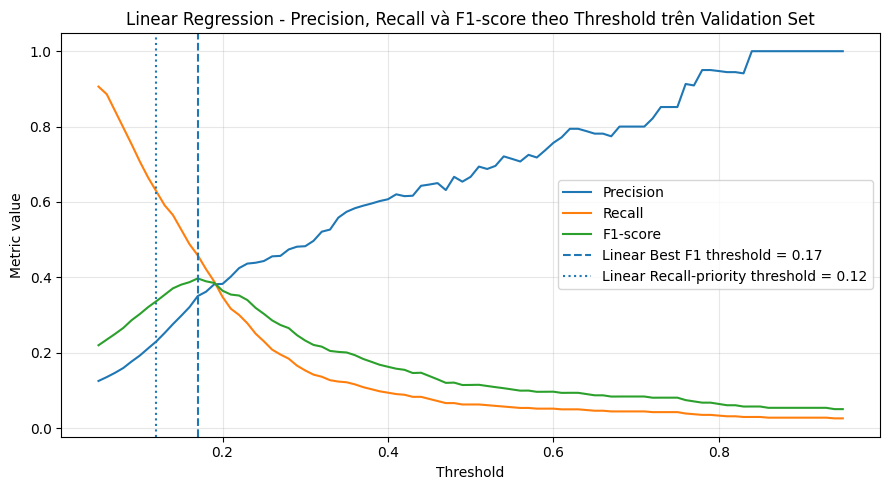

In [44]:
# 14.8. Vẽ Precision, Recall và F1-score theo threshold của Linear Regression

plt.figure(figsize=(9, 5))

plt.plot(
    linear_threshold_results_df["threshold"],
    linear_threshold_results_df["precision"],
    label="Precision",
)

plt.plot(
    linear_threshold_results_df["threshold"],
    linear_threshold_results_df["recall"],
    label="Recall",
)

plt.plot(
    linear_threshold_results_df["threshold"],
    linear_threshold_results_df["f1_score"],
    label="F1-score",
)

plt.axvline(
    linear_best_f1_threshold,
    linestyle="--",
    label=f"Linear Best F1 threshold = {linear_best_f1_threshold:.2f}",
)

plt.axvline(
    linear_recall_priority_threshold,
    linestyle=":",
    label=f"Linear Recall-priority threshold = {linear_recall_priority_threshold:.2f}",
)

plt.xlabel("Threshold")
plt.ylabel("Metric value")
plt.title(
    "Linear Regression - Precision, Recall và F1-score theo Threshold trên Validation Set"
)
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [45]:
# 14.9. Evaluate Linear Regression trên test set với 3 threshold

# Không tune threshold trên test set.
# Ba threshold dưới đây đã được xác định trước:
# - 0.5 là threshold mặc định
# - linear_best_f1_threshold chọn từ validation set
# - linear_recall_priority_threshold chọn từ validation set
linear_test_default_row = collect_result_row(
    model_name="Linear Regression Baseline",
    split_name="Test",
    y_true=y_test,
    y_prob=y_test_prob_linear,
    threshold=0.5,
)

linear_test_best_f1_row = collect_result_row(
    model_name="Linear Regression Baseline",
    split_name="Test",
    y_true=y_test,
    y_prob=y_test_prob_linear,
    threshold=linear_best_f1_threshold,
)

linear_test_recall_priority_row = collect_result_row(
    model_name="Linear Regression Baseline",
    split_name="Test",
    y_true=y_test,
    y_prob=y_test_prob_linear,
    threshold=linear_recall_priority_threshold,
)

linear_test_results_df = pd.DataFrame(
    [
        {
            "setting": "Linear Regression default threshold = 0.5",
            **linear_test_default_row,
        },
        {"setting": "Linear Regression Best F1 threshold", **linear_test_best_f1_row},
        {
            "setting": "Linear Regression Recall-prioritized threshold",
            **linear_test_recall_priority_row,
        },
    ]
)

linear_test_results_df = linear_test_results_df[
    [
        "setting",
        "model",
        "split",
        "threshold",
        "accuracy",
        "precision",
        "recall",
        "f1_score",
        "roc_auc",
        "pr_auc",
    ]
]

linear_test_results_df

,setting,model,split,threshold,accuracy,precision,recall,f1_score,roc_auc,pr_auc
0,Linear Regression default threshold = 0.5,Linear Regression Baseline,Test,0.50,0.917716,0.666667,0.070111,0.126878,0.771,0.310406
1,Linear Regression Best F1 threshold,Linear Regression Baseline,Test,0.17,0.869572,0.300971,0.400369,0.343626,0.771,0.310406
2,Linear Regression Recall-prioritized threshold,Linear Regression Baseline,Test,0.12,0.780522,0.212407,0.581181,0.311111,0.771,0.310406


In [46]:
# 14.10. Tạo prediction variables cho Linear Regression trên test set

y_test_pred_linear_best_f1 = get_predictions_at_threshold(
    y_prob=y_test_prob_linear, threshold=linear_best_f1_threshold
)

y_test_pred_linear_recall_priority = get_predictions_at_threshold(
    y_prob=y_test_prob_linear, threshold=linear_recall_priority_threshold
)

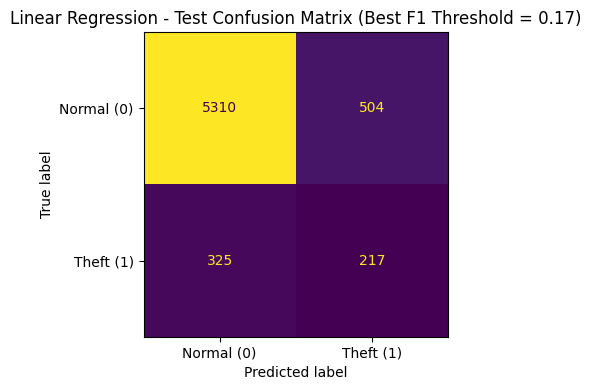

In [47]:
# 14.11. Confusion matrix trên test set với Linear Regression Best F1 threshold

linear_test_best_f1_cm = plot_confusion_matrix_custom(
    y_true=y_test,
    y_pred=y_test_pred_linear_best_f1,
    title=(
        "Linear Regression - Test Confusion Matrix "
        f"(Best F1 Threshold = {linear_best_f1_threshold:.2f})"
    ),
)

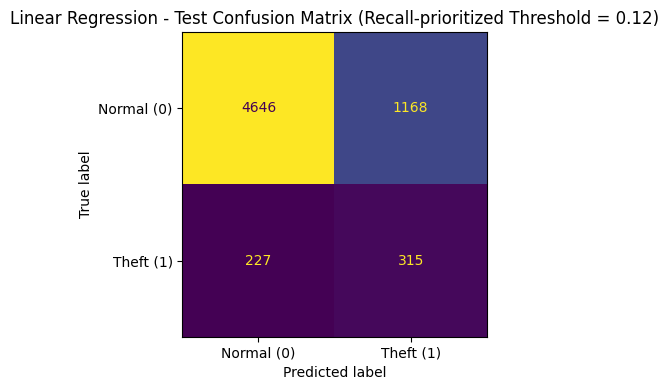

In [48]:
# 14.12. Confusion matrix trên test set với Linear Regression Recall-prioritized threshold

linear_test_recall_priority_cm = plot_confusion_matrix_custom(
    y_true=y_test,
    y_pred=y_test_pred_linear_recall_priority,
    title=(
        "Linear Regression - Test Confusion Matrix "
        f"(Recall-prioritized Threshold = {linear_recall_priority_threshold:.2f})"
    ),
)

In [49]:
# 14.13. So sánh Logistic Regression L2, GDA và Linear Regression trên test set

# Các biến từ các bước trước:
# - test_best_f1_row, test_recall_priority_row: Logistic Regression L2 từ STEP 12
# - gda_test_best_f1_row, gda_test_recall_priority_row: GDA từ STEP 13
# - linear_test_best_f1_row, linear_test_recall_priority_row: Linear Regression từ STEP 14
current_model_comparison_test_df = pd.DataFrame(
    [
        {
            "comparison_setting": "Logistic Regression L2 - Best F1 threshold",
            **test_best_f1_row,
        },
        {"comparison_setting": "GDA - Best F1 threshold", **gda_test_best_f1_row},
        {
            "comparison_setting": "Linear Regression - Best F1 threshold",
            **linear_test_best_f1_row,
        },
        {
            "comparison_setting": "Logistic Regression L2 - Recall-prioritized threshold",
            **test_recall_priority_row,
        },
        {
            "comparison_setting": "GDA - Recall-prioritized threshold",
            **gda_test_recall_priority_row,
        },
        {
            "comparison_setting": "Linear Regression - Recall-prioritized threshold",
            **linear_test_recall_priority_row,
        },
    ]
)

current_model_comparison_test_df = current_model_comparison_test_df[
    [
        "comparison_setting",
        "model",
        "split",
        "threshold",
        "accuracy",
        "precision",
        "recall",
        "f1_score",
        "roc_auc",
        "pr_auc",
    ]
]

current_model_comparison_test_df

,comparison_setting,model,split,threshold,accuracy,precision,recall,f1_score,roc_auc,pr_auc
0,Logistic Regression L2 - Best F1 threshold,Logistic Regression L2 (C=100.0),Test,0.16,0.871145,0.303546,0.394834,0.343224,0.773105,0.311792
1,GDA - Best F1 threshold,Gaussian Discriminant Analysis - LDA,Test,0.14,0.872089,0.299259,0.372694,0.331964,0.772393,0.308164
2,Linear Regression - Best F1 threshold,Linear Regression Baseline,Test,0.17,0.869572,0.300971,0.400369,0.343626,0.771000,0.310406
3,Logistic Regression L2 - Recall-prioritized th...,Logistic Regression L2 (C=100.0),Test,0.11,0.797514,0.224686,0.560886,0.320844,0.773105,0.311792
4,GDA - Recall-prioritized threshold,Gaussian Discriminant Analysis - LDA,Test,0.07,0.768880,0.203455,0.586716,0.302138,0.772393,0.308164
5,Linear Regression - Recall-prioritized threshold,Linear Regression Baseline,Test,0.12,0.780522,0.212407,0.581181,0.311111,0.771000,0.310406


### Nhận xét

+ Kết quả Linear Regression baseline cho thấy mô hình hồi quy tuyến tính vẫn có khả năng xếp hạng tương đối tốt giữa normal và theft customers. Sau khi clip output về khoảng `[0, 1]` và tune threshold trên validation set, Linear Regression đạt hiệu năng khá gần Logistic Regression L2, đặc biệt tại Best F1 threshold.

+ Cụ thể, trên test set tại Best F1 threshold, Linear Regression đạt F1-score = 0.3436, trong khi Logistic Regression L2 đạt F1-score = 0.3432. Mức chênh lệch này rất nhỏ và gần như không đáng kể. Confusion Matrix cũng cho thấy Linear Regression chỉ phát hiện thêm 3 theft customers so với Logistic Regression L2, nhưng đồng thời tạo thêm 13 False Positives.

+ Một điểm đáng chú ý là kết quả này cho thấy các feature được tạo ra trong giai đoạn feature engineering mang tín hiệu tuyến tính khá rõ ràng đối với class theft. Nói cách khác, các feature thống kê và hành vi như zero ratio, volatility, drop pattern, rolling statistics và quality features đã giúp normal và theft customers có thể được phân biệt phần nào bằng một linear score.

+ Tuy nhiên, hiệu năng tương đối tốt của Linear Regression không đồng nghĩa mô hình này phù hợp hơn cho binary classification. Linear Regression không phải là classification model tự nhiên: output gốc của nó không bị giới hạn trong `[0, 1]`, không phải xác suất hợp lệ, và model được tối ưu bằng Mean Squared Error thay vì classification loss. Việc clip score về `[0, 1]` chỉ là xử lý kỹ thuật để có thể so sánh trong cùng framework evaluation, không biến Linear Regression thành một mô hình phân loại đúng nghĩa.

+ Ở Recall-prioritized threshold, Linear Regression đạt Recall cao hơn một chút, nhưng phải đánh đổi bằng số False Positive lớn hơn. Điều này cho thấy Linear Regression có thể tạo ra ranking score có tín hiệu, nhưng trade-off giữa Precision và Recall không tốt hơn rõ rệt so với Logistic Regression L2.

+ Do đó, kết quả của Linear Regression nên được hiểu là bằng chứng cho chất lượng của feature engineering, hơn là bằng chứng rằng Linear Regression phù hợp hơn Logistic Regression. Linear Regression được giữ vai trò baseline phụ để minh họa model suitability, còn Logistic Regression L2 vẫn là model chính phù hợp hơn về mặt phương pháp luận vì mô hình hóa xác suất class theft thông qua sigmoid và được tối ưu trực tiếp cho binary classification.

## 15. Gradient Descent vs Newton Method

Trong bước này, ta minh họa cách **Logistic Regression** tối ưu hàm loss.

Về mặt toán học, Logistic Regression học tham số bằng cách tối thiểu hóa **negative log-likelihood**, tương đương với **binary cross-entropy loss** trong bài toán phân loại nhị phân.

Với mỗi sample, mô hình dự đoán xác suất thuộc class theft:

$$
\hat{y} = \sigma(Xw)
$$

Trong đó:

- $X$ là ma trận feature.
- $w$ là vector tham số.
- $\sigma$ là sigmoid function.
- $\hat{y}$ là xác suất dự đoán class `1 = theft`.

Ta so sánh hai phương pháp tối ưu:

1. **Gradient Descent**  
   Sử dụng gradient bậc nhất để cập nhật tham số từng bước nhỏ theo hướng giảm loss.

2. **Newton Method**  
   Sử dụng cả gradient và Hessian, tức thông tin đạo hàm bậc hai, để cập nhật tham số. Newton Method thường hội tụ với số iteration ít hơn, nhưng mỗi iteration tốn chi phí tính toán lớn hơn.

Vì Newton Method cần tính Hessian có kích thước phụ thuộc vào số feature, ta chỉ chạy phần này trên một **stratified subset nhỏ của train set** để tránh notebook chạy quá nặng.

Lưu ý:

- STEP 15 chỉ là phần **optimization analysis** để phục vụ giải thích học thuật.
- Không thay thế Logistic Regression sklearn đã chọn làm model chính.
- Không dùng test set trong bước này.
- Không tune threshold trong bước này.
- Validation set chỉ được dùng để so sánh metric giữa hai cách tối ưu với threshold mặc định `0.5`.

In [50]:
# STEP 15: Gradient Descent vs Newton Method

import time

from sklearn.model_selection import train_test_split

# 15.1. Chuẩn bị stratified subset từ train set

# Newton Method cần tính Hessian, nên chỉ chạy trên subset nhỏ để tránh quá nặng.
# Subset vẫn được lấy theo stratified sampling để giữ tỷ lệ normal/theft gần giống train set.
optimization_subset_size = 3000

X_train_scaled_array = np.asarray(X_train_scaled)
X_val_scaled_array = np.asarray(X_val_scaled)
y_train_array = np.asarray(y_train)
y_val_array = np.asarray(y_val)

subset_size = min(optimization_subset_size, X_train_scaled_array.shape[0])

_, X_opt_train, _, y_opt_train = train_test_split(
    X_train_scaled_array,
    y_train_array,
    train_size=subset_size,
    stratify=y_train_array,
    random_state=RANDOM_STATE,
)

print("Optimization subset shape:", X_opt_train.shape)
print("Optimization subset class distribution:")
print(pd.Series(y_opt_train).value_counts(normalize=True).sort_index())

Optimization subset shape: (26660, 161)
Optimization subset class distribution:
0    0.914704
1    0.085296
Name: proportion, dtype: float64


In [51]:
# 15.2. Thêm bias/intercept column thủ công


def add_bias_column(X):
    """
    Thêm cột bias/intercept vào ma trận feature.

    Tham số
    -------
    X : array-like
        Ma trận feature ban đầu.

    Trả về
    ------
    np.ndarray
        Ma trận feature sau khi thêm một cột toàn số 1 ở đầu.
    """
    X = np.asarray(X)
    bias = np.ones((X.shape[0], 1))
    return np.hstack([bias, X])


X_opt_train_bias = add_bias_column(X_opt_train)
X_val_bias = add_bias_column(X_val_scaled_array)

print("Train subset with bias shape:", X_opt_train_bias.shape)
print("Validation with bias shape:", X_val_bias.shape)

Train subset with bias shape: (26660, 162)
Validation with bias shape: (6356, 162)


In [52]:
# 15.3. Implement các hàm toán học cho Logistic Regression


def sigmoid(z):
    """
    Tính sigmoid một cách an toàn số học.

    Input được clip để tránh overflow khi z quá lớn hoặc quá nhỏ.
    """
    z = np.clip(z, -500, 500)
    return 1 / (1 + np.exp(-z))


def binary_cross_entropy_loss(X, y, weights, eps=1e-15):
    """
    Tính binary cross-entropy loss, tương đương negative log-likelihood trung bình.

    Tham số
    -------
    X : np.ndarray
        Ma trận feature đã có bias column.
    y : np.ndarray
        Nhãn thật 0/1.
    weights : np.ndarray
        Vector tham số của Logistic Regression.
    eps : float
        Giá trị nhỏ để tránh log(0).

    Trả về
    ------
    float
        Giá trị loss trung bình.
    """
    y = np.asarray(y)
    y_prob = sigmoid(X @ weights)

    # Clip xác suất để tránh log(0).
    y_prob = np.clip(y_prob, eps, 1 - eps)

    loss = -np.mean(y * np.log(y_prob) + (1 - y) * np.log(1 - y_prob))

    return loss


def logistic_gradient(X, y, weights):
    """
    Tính gradient bậc nhất của binary cross-entropy loss.
    """
    n_samples = X.shape[0]
    y_prob = sigmoid(X @ weights)

    gradient = (X.T @ (y_prob - y)) / n_samples

    return gradient


def logistic_hessian(X, weights, damping=1e-4):
    """
    Tính Hessian của Logistic Regression với damping để ổn định số học.

    Damping tương đương thêm một ridge nhỏ vào Hessian,
    giúp tránh trường hợp Hessian singular hoặc gần singular.
    """
    n_samples = X.shape[0]
    y_prob = sigmoid(X @ weights)

    s = y_prob * (1 - y_prob)

    # Tính Hessian = X.T @ diag(s) @ X / n_samples
    # Viết dạng X * s[:, None] để tránh tạo ma trận diag lớn.
    hessian = (X.T @ (X * s[:, None])) / n_samples

    # Thêm damping vào đường chéo để tăng ổn định.
    hessian += damping * np.eye(X.shape[1])

    return hessian


def predict_probability_manual(X, weights):
    """
    Dự đoán xác suất class 1 bằng Logistic Regression tự implement.
    """
    return sigmoid(X @ weights)

In [53]:
# 15.4. Implement Batch Gradient Descent


def train_logistic_regression_gd(
    X,
    y,
    learning_rate=0.1,
    max_iter=500,
    tolerance=1e-7,
):
    """
    Train Logistic Regression bằng Batch Gradient Descent.

    Tham số
    -------
    X : np.ndarray
        Ma trận feature đã có bias column.
    y : np.ndarray
        Nhãn thật 0/1.
    learning_rate : float
        Tốc độ học.
    max_iter : int
        Số iteration tối đa.
    tolerance : float
        Ngưỡng early stopping. Nếu loss cải thiện rất nhỏ thì dừng.

    Trả về
    ------
    weights : np.ndarray
        Vector tham số đã học.
    loss_history : list[float]
        Lịch sử loss theo iteration.
    runtime_seconds : float
        Thời gian chạy tính bằng giây.
    """
    n_features = X.shape[1]
    weights = np.zeros(n_features)

    loss_history = []

    start_time = time.time()

    for iteration in range(max_iter):
        loss = binary_cross_entropy_loss(X, y, weights)
        loss_history.append(loss)

        gradient = logistic_gradient(X, y, weights)
        weights = weights - learning_rate * gradient

        if iteration > 0:
            improvement = abs(loss_history[-2] - loss_history[-1])
            if improvement < tolerance:
                break

    runtime_seconds = time.time() - start_time

    return weights, loss_history, runtime_seconds

In [54]:
# 15.5. Implement Newton Method


def train_logistic_regression_newton(
    X,
    y,
    max_iter=30,
    tolerance=1e-7,
    damping=1e-4,
):
    """
    Train Logistic Regression bằng Newton Method.

    Newton Method dùng cả gradient và Hessian:
        weights_new = weights_old - H^{-1} gradient

    Thay vì tính inverse trực tiếp, ta dùng np.linalg.solve để ổn định hơn:
        H * update = gradient

    Tham số
    -------
    X : np.ndarray
        Ma trận feature đã có bias column.
    y : np.ndarray
        Nhãn thật 0/1.
    max_iter : int
        Số iteration tối đa.
    tolerance : float
        Ngưỡng early stopping.
    damping : float
        Ridge nhỏ thêm vào Hessian để tránh singular matrix.

    Trả về
    ------
    weights : np.ndarray
        Vector tham số đã học.
    loss_history : list[float]
        Lịch sử loss theo iteration.
    runtime_seconds : float
        Thời gian chạy tính bằng giây.
    """
    n_features = X.shape[1]
    weights = np.zeros(n_features)

    loss_history = []

    start_time = time.time()

    for iteration in range(max_iter):
        loss = binary_cross_entropy_loss(X, y, weights)
        loss_history.append(loss)

        gradient = logistic_gradient(X, y, weights)
        hessian = logistic_hessian(X, weights, damping=damping)

        try:
            update = np.linalg.solve(hessian, gradient)
        except np.linalg.LinAlgError:
            # Nếu Hessian vẫn gặp vấn đề số học, tăng damping rồi giải lại.
            stronger_hessian = hessian + (10 * damping) * np.eye(n_features)
            update = np.linalg.solve(stronger_hessian, gradient)

        weights = weights - update

        if iteration > 0:
            improvement = abs(loss_history[-2] - loss_history[-1])
            if improvement < tolerance:
                break

    runtime_seconds = time.time() - start_time

    return weights, loss_history, runtime_seconds

In [55]:
# 15.6. Train Logistic Regression bằng Gradient Descent và Newton Method

gd_weights, gd_loss_history, gd_runtime_seconds = train_logistic_regression_gd(
    X=X_opt_train_bias, y=y_opt_train, learning_rate=0.1, max_iter=500, tolerance=1e-7
)

newton_weights, newton_loss_history, newton_runtime_seconds = (
    train_logistic_regression_newton(
        X=X_opt_train_bias, y=y_opt_train, max_iter=30, tolerance=1e-7, damping=1e-4
    )
)

print("Gradient Descent:")
print(f"- Iterations      : {len(gd_loss_history)}")
print(f"- Final train loss: {gd_loss_history[-1]:.6f}")
print(f"- Runtime seconds : {gd_runtime_seconds:.4f}")

print("\nNewton Method:")
print(f"- Iterations      : {len(newton_loss_history)}")
print(f"- Final train loss: {newton_loss_history[-1]:.6f}")
print(f"- Runtime seconds : {newton_runtime_seconds:.4f}")

Gradient Descent:
- Iterations      : 500
- Final train loss: 0.251652
- Runtime seconds : 1.9230

Newton Method:
- Iterations      : 30
- Final train loss: 0.242964
- Runtime seconds : 0.6933


In [56]:
# 15.7. Predict probability trên validation set

# Không dùng test set trong STEP 15.
# Validation set chỉ được dùng để so sánh hai phương pháp tối ưu với threshold mặc định 0.5.
y_val_prob_gd = predict_probability_manual(X_val_bias, gd_weights)
y_val_prob_newton = predict_probability_manual(X_val_bias, newton_weights)

optimization_threshold = 0.5

gd_val_row = collect_result_row(
    model_name="Manual Logistic Regression - Gradient Descent",
    split_name="Validation",
    y_true=y_val_array,
    y_prob=y_val_prob_gd,
    threshold=optimization_threshold,
)

newton_val_row = collect_result_row(
    model_name="Manual Logistic Regression - Newton Method",
    split_name="Validation",
    y_true=y_val_array,
    y_prob=y_val_prob_newton,
    threshold=optimization_threshold,
)

In [57]:
# 15.8. Tạo bảng so sánh Gradient Descent và Newton Method

optimization_comparison_df = pd.DataFrame(
    [
        {
            "method": "Gradient Descent",
            "iterations": len(gd_loss_history),
            "final_train_loss": gd_loss_history[-1],
            "runtime_seconds": gd_runtime_seconds,
            "validation_accuracy": gd_val_row["accuracy"],
            "validation_precision": gd_val_row["precision"],
            "validation_recall": gd_val_row["recall"],
            "validation_f1_score": gd_val_row["f1_score"],
            "validation_roc_auc": gd_val_row["roc_auc"],
            "validation_pr_auc": gd_val_row["pr_auc"],
        },
        {
            "method": "Newton Method",
            "iterations": len(newton_loss_history),
            "final_train_loss": newton_loss_history[-1],
            "runtime_seconds": newton_runtime_seconds,
            "validation_accuracy": newton_val_row["accuracy"],
            "validation_precision": newton_val_row["precision"],
            "validation_recall": newton_val_row["recall"],
            "validation_f1_score": newton_val_row["f1_score"],
            "validation_roc_auc": newton_val_row["roc_auc"],
            "validation_pr_auc": newton_val_row["pr_auc"],
        },
    ]
)

optimization_comparison_df

,method,iterations,final_train_loss,runtime_seconds,validation_accuracy,validation_precision,validation_recall,validation_f1_score,validation_roc_auc,validation_pr_auc
0,Gradient Descent,500,0.251652,1.923025,0.918345,0.722222,0.071823,0.130653,0.784925,0.325534
1,Newton Method,30,0.242964,0.693328,0.917401,0.586538,0.112339,0.188563,0.792862,0.344740


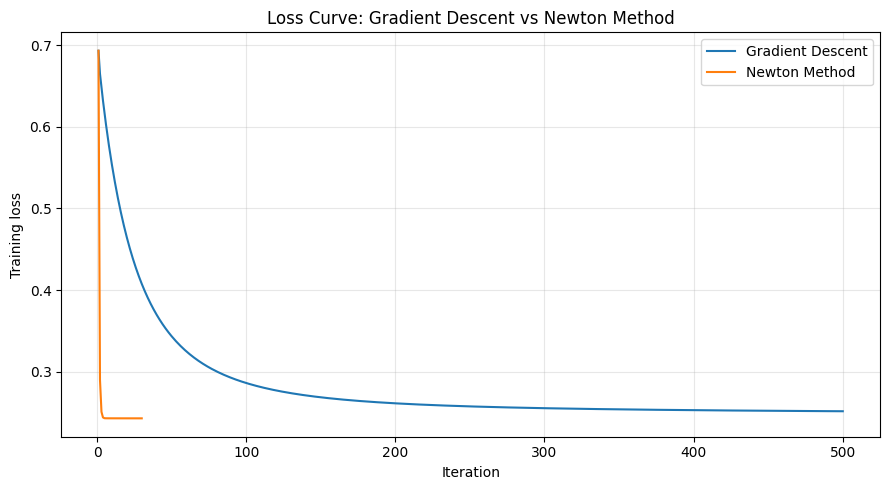

In [58]:
# 15.9. Vẽ loss curve so sánh Gradient Descent và Newton Method

plt.figure(figsize=(9, 5))

plt.plot(range(1, len(gd_loss_history) + 1), gd_loss_history, label="Gradient Descent")

plt.plot(
    range(1, len(newton_loss_history) + 1), newton_loss_history, label="Newton Method"
)

plt.xlabel("Iteration")
plt.ylabel("Training loss")
plt.title("Loss Curve: Gradient Descent vs Newton Method")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### Nhận Xét:

+ Kết quả so sánh cho thấy Newton Method hội tụ nhanh hơn Gradient Descent trong thí nghiệm tối ưu Logistic Regression trên subset của train set.

+ Gradient Descent cần chạy đủ 500 iterations và đạt final train loss = 0.251652. Trong khi đó, Newton Method chỉ cần 30 iterations nhưng đạt final train loss thấp hơn, bằng 0.242964. Loss curve cũng cho thấy Newton Method giảm loss rất nhanh trong các iteration đầu, còn Gradient Descent giảm loss chậm và đều hơn.

+ Trên validation set, Newton Method cũng đạt kết quả tốt hơn ở các metric quan trọng cho bài toán mất cân bằng như Recall, F1-score, ROC-AUC và PR-AUC. Cụ thể, Newton Method đạt F1-score = 0.188563 và PR-AUC = 0.344740, trong khi Gradient Descent đạt F1-score = 0.130653 và PR-AUC = 0.325534.

+ Điều này phù hợp với lý thuyết: Gradient Descent chỉ sử dụng thông tin gradient bậc nhất, còn Newton Method sử dụng thêm Hessian, tức thông tin độ cong của loss function, nên có thể chọn bước cập nhật hiệu quả hơn và hội tụ nhanh hơn.

+ Tuy nhiên, mỗi iteration của Newton Method tốn chi phí tính toán lớn hơn do cần xây dựng Hessian và giải hệ phương trình tuyến tính. Trong thí nghiệm này, Newton Method vẫn có runtime thấp hơn Gradient Descent vì dữ liệu chỉ là subset nhỏ và số iteration ít hơn nhiều. Với dataset lớn hơn hoặc số feature cao hơn, chi phí Hessian có thể khiến Newton Method trở nên nặng hơn.

+ Do đó, STEP 15 không nhằm thay thế Logistic Regression sklearn làm model chính, mà đóng vai trò minh họa sự khác biệt giữa hai phương pháp tối ưu. Model chính của project vẫn là Logistic Regression L2 đã được chọn và đánh giá ở các bước trước.

## 16. Weighted Logistic Regression

Ở các bước trước, Logistic Regression L2 thông thường cho kết quả ổn định về mặt ROC-AUC và PR-AUC, nhưng F1-score và Recall vẫn còn thấp. Nguyên nhân chính là dataset bị mất cân bằng mạnh: class `1 = theft` chiếm tỷ lệ nhỏ hơn nhiều so với class `0 = normal`.

Khi dữ liệu mất cân bằng, mô hình có xu hướng ưu tiên class majority để giảm loss tổng thể. Điều này có thể làm Accuracy cao nhưng Recall của class theft thấp, tức model bỏ sót nhiều khách hàng theft thật.

Trong bước này, ta thử **Weighted Logistic Regression** bằng cách sử dụng `class_weight="balanced"`.

`class_weight="balanced"` tự động gán trọng số lớn hơn cho class ít mẫu hơn. Với bài toán này, lỗi trên class theft sẽ được mô hình xem là quan trọng hơn trong quá trình tối ưu loss function.

### Class weighting khác gì threshold tuning?

- **Class weighting** thay đổi quá trình training bằng cách thay đổi trọng số lỗi của từng class trong loss function.
- **Threshold tuning** không thay đổi model, chỉ thay đổi ngưỡng chuyển xác suất thành nhãn `0/1`.

Nói cách khác, class weighting tác động vào **cách model học**, còn threshold tuning tác động vào **cách model ra quyết định sau khi đã học xong**.

### Vì sao không dùng Negative Sampling ở bước này?

Class weighting an toàn hơn Negative Sampling trong project này vì:

- Không loại bỏ bớt dữ liệu normal.
- Không làm mất thông tin từ majority class.
- Không tạo dữ liệu nhân tạo.
- Vẫn giữ nguyên pipeline train/validation/test hiện tại.

Vì normal customers có thể có nhiều kiểu hành vi tiêu thụ điện hợp lệ khác nhau, việc loại bỏ bớt normal samples bằng Negative Sampling có thể làm mất thông tin quan trọng và làm tăng False Positive. Do đó, nhóm ưu tiên dùng class weighting vì phương pháp này xử lý imbalance trong loss function mà không thay đổi dữ liệu huấn luyện.

### Lưu ý quan trọng

- Validation set được dùng để chọn `C` và threshold.
- Test set chỉ dùng sau khi đã chọn xong `C` và threshold.
- Không dùng test set để chọn model, chọn `C`, hoặc tune threshold.
- Weighted Logistic Regression chưa được xem là model cuối cùng ngay lập tức, nó cần được so sánh với các model trước ở bước Final Model Comparison.

In [59]:
# STEP 16: Weighted Logistic Regression

from sklearn.linear_model import LogisticRegression

# 16.1. Search C cho Logistic Regression L2 với class_weight="balanced"

# Grid C theo log-scale.
# C nhỏ: regularization mạnh hơn.
# C lớn: regularization yếu hơn.
C_values_weighted = [0.001, 0.003, 0.01, 0.03, 0.1, 0.3, 1.0, 3.0, 10.0, 30.0, 100.0]

weighted_logreg_result_rows = []
weighted_logreg_models = {}
weighted_logreg_val_probabilities = {}

weighted_default_threshold = 0.5

for C in C_values_weighted:
    model_name = f"Weighted Logistic Regression L2 (C={C})"

    weighted_logreg = LogisticRegression(
        penalty="l2",
        C=C,
        class_weight="balanced",
        solver="lbfgs",
        max_iter=5000,
        random_state=RANDOM_STATE,
    )

    # Train model trên train set.
    # Không dùng validation hoặc test trong quá trình fit.
    weighted_logreg.fit(X_train_scaled, y_train)

    # Dự đoán xác suất class 1 = theft trên validation set.
    y_val_prob_weighted = weighted_logreg.predict_proba(X_val_scaled)[:, 1]

    # Evaluate validation set với threshold mặc định 0.5.
    result_row = collect_result_row(
        model_name=model_name,
        split_name="Validation",
        y_true=y_val,
        y_prob=y_val_prob_weighted,
        threshold=weighted_default_threshold,
    )

    result_row["C"] = C

    weighted_logreg_result_rows.append(result_row)
    weighted_logreg_models[C] = weighted_logreg
    weighted_logreg_val_probabilities[C] = y_val_prob_weighted


weighted_logreg_results_df = pd.DataFrame(weighted_logreg_result_rows)

# Sắp xếp theo thứ tự ưu tiên:
# 1. pr_auc giảm dần
# 2. f1_score giảm dần
# 3. recall giảm dần
weighted_logreg_results_df = weighted_logreg_results_df.sort_values(
    by=["pr_auc", "f1_score", "recall"], ascending=[False, False, False]
).reset_index(drop=True)

weighted_logreg_results_df

,model,split,threshold,accuracy,precision,recall,f1_score,roc_auc,pr_auc,C
0,Weighted Logistic Regression L2 (C=100.0),Validation,0.5,0.749685,0.207263,0.683241,0.318045,0.802364,0.350179,100.000
1,Weighted Logistic Regression L2 (C=10.0),Validation,0.5,0.748899,0.207012,0.685083,0.317949,0.802402,0.350020,10.000
2,Weighted Logistic Regression L2 (C=3.0),Validation,0.5,0.749056,0.206473,0.681400,0.316916,0.802476,0.349993,3.000
3,Weighted Logistic Regression L2 (C=30.0),Validation,0.5,0.748427,0.206667,0.685083,0.317542,0.802135,0.349965,30.000
4,Weighted Logistic Regression L2 (C=1.0),Validation,0.5,0.749213,0.207893,0.688766,0.319385,0.802627,0.349044,1.000
5,Weighted Logistic Regression L2 (C=0.3),Validation,0.5,0.747483,0.206630,0.688766,0.317892,0.801095,0.345851,0.300
6,Weighted Logistic Regression L2 (C=0.1),Validation,0.5,0.745595,0.205592,0.690608,0.316857,0.801371,0.344460,0.100
7,Weighted Logistic Regression L2 (C=0.03),Validation,0.5,0.741189,0.203125,0.694291,0.314298,0.800768,0.342399,0.030
8,Weighted Logistic Regression L2 (C=0.01),Validation,0.5,0.737571,0.201592,0.699816,0.313015,0.798796,0.338724,0.010
9,Weighted Logistic Regression L2 (C=0.003),Validation,0.5,0.733638,0.201454,0.714549,0.314297,0.796350,0.333486,0.003


In [60]:
# 16.2. Chọn best weighted Logistic Regression trên validation set

weighted_logreg_best_row = weighted_logreg_results_df.iloc[0].to_dict()

weighted_logreg_best_C = weighted_logreg_best_row["C"]
weighted_logreg_best = weighted_logreg_models[weighted_logreg_best_C]
y_val_prob_weighted_logreg_best = weighted_logreg_val_probabilities[
    weighted_logreg_best_C
]

# Predict probability trên test set chỉ sau khi best C đã được chọn từ validation set.
# Không dùng test set để chọn C.
y_test_prob_weighted_logreg_best = weighted_logreg_best.predict_proba(X_test_scaled)[
    :, 1
]

print("Best Weighted Logistic Regression trên validation set")
print(f"Best C       : {weighted_logreg_best_C}")
print(f"PR-AUC       : {weighted_logreg_best_row['pr_auc']:.6f}")
print(f"F1-score     : {weighted_logreg_best_row['f1_score']:.6f}")
print(f"Recall       : {weighted_logreg_best_row['recall']:.6f}")
print(f"Precision    : {weighted_logreg_best_row['precision']:.6f}")
print(f"Accuracy     : {weighted_logreg_best_row['accuracy']:.6f}")
print(f"ROC-AUC      : {weighted_logreg_best_row['roc_auc']:.6f}")

Best Weighted Logistic Regression trên validation set
Best C       : 100.0
PR-AUC       : 0.350179
F1-score     : 0.318045
Recall       : 0.683241
Precision    : 0.207263
Accuracy     : 0.749685
ROC-AUC      : 0.802364


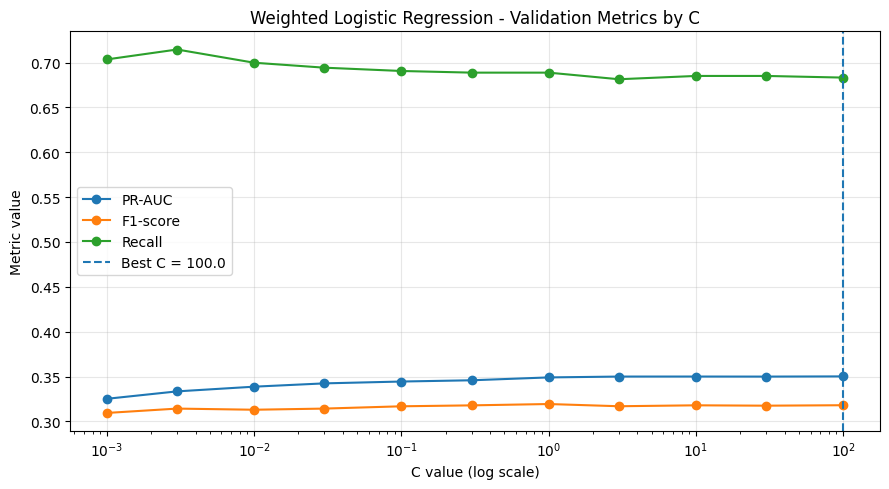

In [61]:
# 16.3. Vẽ PR-AUC, F1-score và Recall theo C trên validation set

# Vẽ theo thứ tự C tăng dần để quan sát xu hướng dễ hơn.
weighted_logreg_plot_df = weighted_logreg_results_df.sort_values("C").reset_index(
    drop=True
)

plt.figure(figsize=(9, 5))

plt.plot(
    weighted_logreg_plot_df["C"],
    weighted_logreg_plot_df["pr_auc"],
    marker="o",
    label="PR-AUC",
)

plt.plot(
    weighted_logreg_plot_df["C"],
    weighted_logreg_plot_df["f1_score"],
    marker="o",
    label="F1-score",
)

plt.plot(
    weighted_logreg_plot_df["C"],
    weighted_logreg_plot_df["recall"],
    marker="o",
    label="Recall",
)

plt.axvline(
    weighted_logreg_best_C, linestyle="--", label=f"Best C = {weighted_logreg_best_C}"
)

plt.xscale("log")
plt.xlabel("C value (log scale)")
plt.ylabel("Metric value")
plt.title("Weighted Logistic Regression - Validation Metrics by C")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [62]:
# 16.4. Threshold tuning cho Weighted Logistic Regression trên validation set

weighted_thresholds = np.arange(0.05, 0.96, 0.01)

weighted_threshold_result_rows = []

for threshold in weighted_thresholds:
    result_row = collect_result_row(
        model_name=f"Weighted Logistic Regression L2 (C={weighted_logreg_best_C})",
        split_name="Validation",
        y_true=y_val,
        y_prob=y_val_prob_weighted_logreg_best,
        threshold=threshold,
    )

    weighted_threshold_result_rows.append(result_row)


weighted_threshold_results_df = pd.DataFrame(weighted_threshold_result_rows)

weighted_threshold_results_df = weighted_threshold_results_df[
    [
        "model",
        "split",
        "threshold",
        "accuracy",
        "precision",
        "recall",
        "f1_score",
        "roc_auc",
        "pr_auc",
    ]
]

weighted_threshold_results_df.head()

,model,split,threshold,accuracy,precision,recall,f1_score,roc_auc,pr_auc
0,Weighted Logistic Regression L2 (C=100.0),Validation,0.05,0.116268,0.088016,0.998158,0.161767,0.802364,0.350179
1,Weighted Logistic Regression L2 (C=100.0),Validation,0.06,0.128383,0.089130,0.998158,0.163647,0.802364,0.350179
2,Weighted Logistic Regression L2 (C=100.0),Validation,0.07,0.140654,0.090288,0.998158,0.165597,0.802364,0.350179
3,Weighted Logistic Regression L2 (C=100.0),Validation,0.08,0.148993,0.090817,0.994475,0.166436,0.802364,0.350179
4,Weighted Logistic Regression L2 (C=100.0),Validation,0.09,0.155601,0.091463,0.994475,0.167520,0.802364,0.350179


In [63]:
# 16.5. Tìm Best F1 threshold cho Weighted Logistic Regression

# Nếu nhiều threshold có cùng F1-score, ưu tiên recall cao hơn,
# sau đó precision cao hơn.
weighted_best_f1_row = (
    weighted_threshold_results_df.sort_values(
        by=["f1_score", "recall", "precision"], ascending=[False, False, False]
    )
    .iloc[0]
    .to_dict()
)

weighted_best_f1_threshold = weighted_best_f1_row["threshold"]

print("Weighted Logistic Regression - Best F1 threshold trên validation set")
print(f"Threshold : {weighted_best_f1_threshold:.2f}")
print(f"Precision : {weighted_best_f1_row['precision']:.6f}")
print(f"Recall    : {weighted_best_f1_row['recall']:.6f}")
print(f"F1-score  : {weighted_best_f1_row['f1_score']:.6f}")
print(f"PR-AUC    : {weighted_best_f1_row['pr_auc']:.6f}")
print(f"ROC-AUC   : {weighted_best_f1_row['roc_auc']:.6f}")

Weighted Logistic Regression - Best F1 threshold trên validation set
Threshold : 0.70
Precision : 0.377049
Recall    : 0.423573
F1-score  : 0.398959
PR-AUC    : 0.350179
ROC-AUC   : 0.802364


In [64]:
# 16.6. Tìm Recall-prioritized threshold cho Weighted Logistic Regression

# Chiến lược:
# - Nếu tồn tại threshold có recall >= 0.60:
#     chọn threshold có f1_score cao nhất trong nhóm đó.
# - Nếu không tồn tại:
#     chọn threshold có recall cao nhất, sau đó f1_score cao nhất.
weighted_recall_target = 0.60

weighted_recall_candidate_df = weighted_threshold_results_df[
    weighted_threshold_results_df["recall"] >= weighted_recall_target
].copy()

if len(weighted_recall_candidate_df) > 0:
    weighted_recall_priority_row = (
        weighted_recall_candidate_df.sort_values(
            by=["f1_score", "precision", "recall"], ascending=[False, False, False]
        )
        .iloc[0]
        .to_dict()
    )

    print(
        f"Tìm thấy threshold Weighted Logistic Regression đạt recall >= {weighted_recall_target:.2f}."
    )
    print("Chọn threshold có F1-score cao nhất trong nhóm này.")

else:
    weighted_recall_priority_row = (
        weighted_threshold_results_df.sort_values(
            by=["recall", "f1_score", "precision"], ascending=[False, False, False]
        )
        .iloc[0]
        .to_dict()
    )

    print(
        f"Không có threshold Weighted Logistic Regression nào đạt recall >= {weighted_recall_target:.2f}."
    )
    print("Chọn threshold có Recall cao nhất, sau đó F1-score cao nhất.")


weighted_recall_priority_threshold = weighted_recall_priority_row["threshold"]

print(
    "\nWeighted Logistic Regression - Recall-prioritized threshold trên validation set"
)
print(f"Threshold : {weighted_recall_priority_threshold:.2f}")
print(f"Precision : {weighted_recall_priority_row['precision']:.6f}")
print(f"Recall    : {weighted_recall_priority_row['recall']:.6f}")
print(f"F1-score  : {weighted_recall_priority_row['f1_score']:.6f}")
print(f"PR-AUC    : {weighted_recall_priority_row['pr_auc']:.6f}")
print(f"ROC-AUC   : {weighted_recall_priority_row['roc_auc']:.6f}")

Tìm thấy threshold Weighted Logistic Regression đạt recall >= 0.60.
Chọn threshold có F1-score cao nhất trong nhóm này.

Weighted Logistic Regression - Recall-prioritized threshold trên validation set
Threshold : 0.56
Precision : 0.251727
Recall    : 0.604052
F1-score  : 0.355363
PR-AUC    : 0.350179
ROC-AUC   : 0.802364


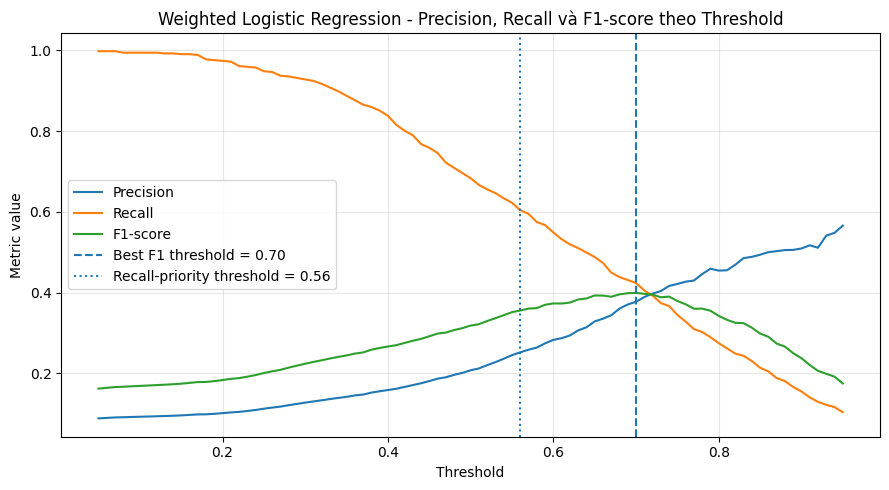

In [65]:
# 16.7. Vẽ Precision, Recall và F1-score theo threshold trên validation set

plt.figure(figsize=(9, 5))

plt.plot(
    weighted_threshold_results_df["threshold"],
    weighted_threshold_results_df["precision"],
    label="Precision",
)

plt.plot(
    weighted_threshold_results_df["threshold"],
    weighted_threshold_results_df["recall"],
    label="Recall",
)

plt.plot(
    weighted_threshold_results_df["threshold"],
    weighted_threshold_results_df["f1_score"],
    label="F1-score",
)

plt.axvline(
    weighted_best_f1_threshold,
    linestyle="--",
    label=f"Best F1 threshold = {weighted_best_f1_threshold:.2f}",
)

plt.axvline(
    weighted_recall_priority_threshold,
    linestyle=":",
    label=f"Recall-priority threshold = {weighted_recall_priority_threshold:.2f}",
)

plt.xlabel("Threshold")
plt.ylabel("Metric value")
plt.title("Weighted Logistic Regression - Precision, Recall và F1-score theo Threshold")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [66]:
# 16.8. Evaluate Weighted Logistic Regression trên test set với 3 threshold

# Không dùng test set để chọn threshold.
# Các threshold dưới đây đã được xác định trước từ validation set.
weighted_test_default_row = collect_result_row(
    model_name=f"Weighted Logistic Regression L2 (C={weighted_logreg_best_C})",
    split_name="Test",
    y_true=y_test,
    y_prob=y_test_prob_weighted_logreg_best,
    threshold=0.5,
)

weighted_test_best_f1_row = collect_result_row(
    model_name=f"Weighted Logistic Regression L2 (C={weighted_logreg_best_C})",
    split_name="Test",
    y_true=y_test,
    y_prob=y_test_prob_weighted_logreg_best,
    threshold=weighted_best_f1_threshold,
)

weighted_test_recall_priority_row = collect_result_row(
    model_name=f"Weighted Logistic Regression L2 (C={weighted_logreg_best_C})",
    split_name="Test",
    y_true=y_test,
    y_prob=y_test_prob_weighted_logreg_best,
    threshold=weighted_recall_priority_threshold,
)

weighted_logreg_test_results_df = pd.DataFrame(
    [
        {
            "setting": "Weighted Logistic Regression default threshold = 0.5",
            **weighted_test_default_row,
        },
        {
            "setting": "Weighted Logistic Regression Best F1 threshold",
            **weighted_test_best_f1_row,
        },
        {
            "setting": "Weighted Logistic Regression Recall-prioritized threshold",
            **weighted_test_recall_priority_row,
        },
    ]
)

weighted_logreg_test_results_df = weighted_logreg_test_results_df[
    [
        "setting",
        "model",
        "split",
        "threshold",
        "accuracy",
        "precision",
        "recall",
        "f1_score",
        "roc_auc",
        "pr_auc",
    ]
]

weighted_logreg_test_results_df

,setting,model,split,threshold,accuracy,precision,recall,f1_score,roc_auc,pr_auc
0,Weighted Logistic Regression default threshold...,Weighted Logistic Regression L2 (C=100.0),Test,0.50,0.743392,0.196995,0.653137,0.302693,0.774308,0.308545
1,Weighted Logistic Regression Best F1 threshold,Weighted Logistic Regression L2 (C=100.0),Test,0.70,0.880113,0.322581,0.369004,0.344234,0.774308,0.308545
2,Weighted Logistic Regression Recall-prioritize...,Weighted Logistic Regression L2 (C=100.0),Test,0.56,0.803021,0.225657,0.538745,0.318083,0.774308,0.308545


In [67]:
# 16.9. Tạo prediction variables trên test set

y_test_pred_weighted_best_f1 = get_predictions_at_threshold(
    y_prob=y_test_prob_weighted_logreg_best, threshold=weighted_best_f1_threshold
)

y_test_pred_weighted_recall_priority = get_predictions_at_threshold(
    y_prob=y_test_prob_weighted_logreg_best,
    threshold=weighted_recall_priority_threshold,
)

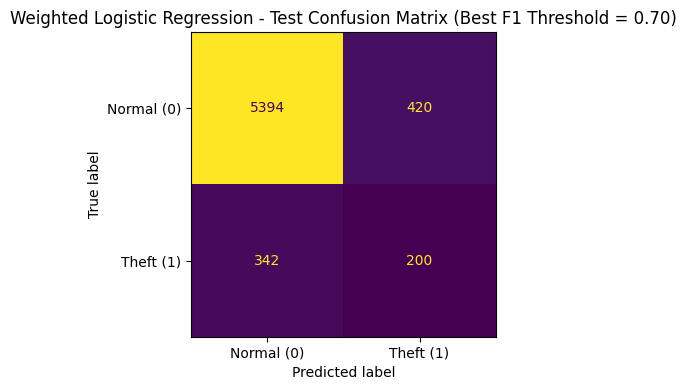

In [68]:
# 16.10. Confusion matrix trên test set với Weighted Best F1 threshold

weighted_test_best_f1_cm = plot_confusion_matrix_custom(
    y_true=y_test,
    y_pred=y_test_pred_weighted_best_f1,
    title=(
        "Weighted Logistic Regression - Test Confusion Matrix "
        f"(Best F1 Threshold = {weighted_best_f1_threshold:.2f})"
    ),
)

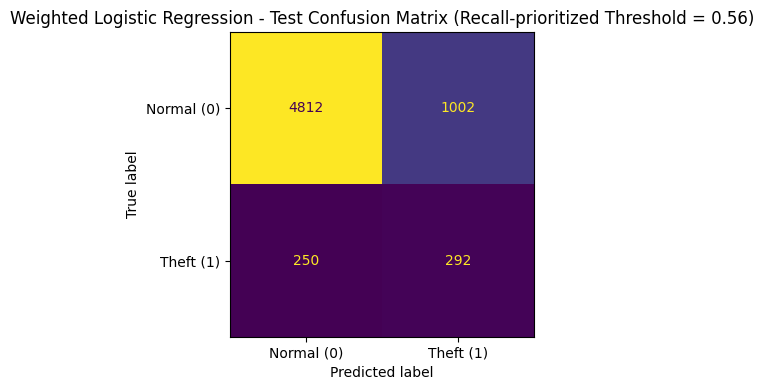

In [69]:
# 16.11. Confusion matrix trên test set với Weighted Recall-prioritized threshold

weighted_test_recall_priority_cm = plot_confusion_matrix_custom(
    y_true=y_test,
    y_pred=y_test_pred_weighted_recall_priority,
    title=(
        "Weighted Logistic Regression - Test Confusion Matrix "
        f"(Recall-prioritized Threshold = {weighted_recall_priority_threshold:.2f})"
    ),
)

In [70]:
# 16.12. So sánh Logistic Regression L2 thường và Weighted Logistic Regression trên test set

# Các biến test_best_f1_row và test_recall_priority_row đến từ STEP 12.
# Chúng là kết quả của Logistic Regression L2 thường trên test set.
weighted_vs_unweighted_logreg_df = pd.DataFrame(
    [
        {
            "comparison_setting": "Logistic Regression L2 - Best F1 threshold",
            **test_best_f1_row,
        },
        {
            "comparison_setting": "Weighted Logistic Regression - Best F1 threshold",
            **weighted_test_best_f1_row,
        },
        {
            "comparison_setting": "Logistic Regression L2 - Recall-prioritized threshold",
            **test_recall_priority_row,
        },
        {
            "comparison_setting": "Weighted Logistic Regression - Recall-prioritized threshold",
            **weighted_test_recall_priority_row,
        },
    ]
)

weighted_vs_unweighted_logreg_df = weighted_vs_unweighted_logreg_df[
    [
        "comparison_setting",
        "model",
        "split",
        "threshold",
        "accuracy",
        "precision",
        "recall",
        "f1_score",
        "roc_auc",
        "pr_auc",
    ]
]

weighted_vs_unweighted_logreg_df

,comparison_setting,model,split,threshold,accuracy,precision,recall,f1_score,roc_auc,pr_auc
0,Logistic Regression L2 - Best F1 threshold,Logistic Regression L2 (C=100.0),Test,0.16,0.871145,0.303546,0.394834,0.343224,0.773105,0.311792
1,Weighted Logistic Regression - Best F1 threshold,Weighted Logistic Regression L2 (C=100.0),Test,0.70,0.880113,0.322581,0.369004,0.344234,0.774308,0.308545
2,Logistic Regression L2 - Recall-prioritized th...,Logistic Regression L2 (C=100.0),Test,0.11,0.797514,0.224686,0.560886,0.320844,0.773105,0.311792
3,Weighted Logistic Regression - Recall-prioriti...,Weighted Logistic Regression L2 (C=100.0),Test,0.56,0.803021,0.225657,0.538745,0.318083,0.774308,0.308545


### Nhận xét

+ Kết quả Weighted Logistic Regression cho thấy việc sử dụng `class_weight="balanced"` không cải thiện đáng kể hiệu năng tổng thể so với Logistic Regression L2 thông thường.

+ Trên test set tại Best F1 threshold, Weighted Logistic Regression đạt F1-score = 0.3442, chỉ nhỉnh hơn rất nhẹ so với Logistic Regression L2 thông thường với F1-score = 0.3432. Precision tăng từ 0.3035 lên 0.3226, nhưng Recall giảm từ 0.3948 xuống 0.3690. Điều này cho thấy class weighting giúp model thận trọng hơn ở threshold tối ưu theo F1, nhưng không cải thiện rõ rệt khả năng phát hiện theft.

+ Ở Recall-prioritized setting, Weighted Logistic Regression cũng không vượt trội so với Logistic Regression L2 thông thường. Recall giảm từ 0.5609 xuống 0.5387, trong khi F1-score cũng giảm nhẹ từ 0.3208 xuống 0.3181.

+ Một điểm đáng chú ý là threshold tối ưu của Weighted Logistic Regression cao hơn nhiều so với Logistic Regression L2 thường. Điều này cho thấy `class_weight="balanced"` đã làm thay đổi phân phối xác suất dự đoán, khiến model gán xác suất theft cao hơn cho nhiều mẫu. Tuy nhiên, PR-AUC không tăng mà còn giảm nhẹ, cho thấy class weighting chủ yếu ảnh hưởng đến calibration hoặc decision boundary, chứ chưa cải thiện đáng kể khả năng ranking theft customers.

+ Kết quả này cho thấy Logistic Regression family, dù phù hợp và dễ giải thích về mặt phương pháp luận, có thể đã chạm giới hạn biểu diễn trên bộ feature hiện tại. Bài toán energy theft có thể chứa các quan hệ phi tuyến hoặc tương tác phức tạp giữa các feature mà mô hình tuyến tính khó nắm bắt đầy đủ.

+ Do đó, Weighted Logistic Regression được giữ như một thí nghiệm imbalance-aware quan trọng, nhưng chưa đủ bằng chứng để thay thế Logistic Regression L2 thường làm model chính. Bước tiếp theo cần thử một model phi tuyến trong phạm vi môn học, chẳng hạn Random Forest, để kiểm tra liệu việc học các tương tác phi tuyến giữa feature có cải thiện khả năng phát hiện theft hay không.

## 17. Random Forest Classifier

Ở các bước trước, Logistic Regression L2 và Weighted Logistic Regression đều là các mô hình tuyến tính. Các mô hình này phù hợp về mặt phương pháp luận cho binary classification, nhưng kết quả F1-score và Recall vẫn còn giới hạn. Điều này cho thấy Logistic Regression family có thể chưa biểu diễn tốt các quan hệ phức tạp trong dữ liệu energy theft.

Trong bước này, ta thử **Random Forest Classifier** như một model phi tuyến mở rộng.

Random Forest là một ensemble model được xây dựng từ nhiều **Decision Tree**. Mỗi cây học một phần khác nhau của dữ liệu, sau đó Random Forest kết hợp dự đoán của nhiều cây để tạo kết quả ổn định hơn so với một cây đơn lẻ.

Random Forest có thể phù hợp hơn Logistic Regression trong trường hợp này vì:

- Có thể học quan hệ **phi tuyến** giữa các feature.
- Có thể khai thác **interaction phức tạp** giữa các feature như missing pattern, zero ratio, drop ratio, rolling statistics.
- Ít phụ thuộc vào giả định linear decision boundary.

Ta dùng `class_weight="balanced_subsample"` để hỗ trợ imbalanced dataset. Với Random Forest, option này tính class weight trên từng bootstrap sample của mỗi cây, giúp từng cây quan tâm hơn đến class minority mà không cần oversampling hoặc undersampling.

Trong STEP 17:

- Validation set được dùng để chọn hyperparameter và threshold.
- Test set chỉ được dùng sau khi đã chọn xong model và threshold.
- Không dùng test set để chọn model.
- Không dùng Negative Sampling, Oversampling, Gradient Boosting, XGBoost, LightGBM hoặc CatBoost.
- Random Forest chưa được xem là model cuối cùng ngay lập tức, kết quả sẽ được đưa vào Final Model Comparison.

Gradient Boosting/XGBoost không được dùng ở bước này vì nằm ngoài phạm vi hiện tại của project và môn học. Random Forest đủ phù hợp để minh họa ensemble learning dựa trên Decision Tree.

In [71]:
# STEP 17: Random Forest Classifier

import time

from sklearn.ensemble import RandomForestClassifier

# 17.1. Khai báo grid nhỏ cho Random Forest

# Random Forest không bắt buộc scaling.
# Tuy nhiên, để nhất quán với notebook hiện tại, ta dùng X_train_scaled / X_val_scaled / X_test_scaled.
#
# class_weight="balanced_subsample":
# - Phù hợp với Random Forest.
# - Tính class weight riêng trên từng bootstrap sample.
# - Giúp mỗi cây quan tâm hơn đến class minority mà không cần resampling.
rf_param_grid = [
    {
        "n_estimators": 100,
        "max_depth": 8,
        "min_samples_leaf": 5,
        "max_features": "sqrt",
        "class_weight": "balanced_subsample",
    },
    {
        "n_estimators": 200,
        "max_depth": 8,
        "min_samples_leaf": 5,
        "max_features": "sqrt",
        "class_weight": "balanced_subsample",
    },
    {
        "n_estimators": 200,
        "max_depth": 12,
        "min_samples_leaf": 5,
        "max_features": "sqrt",
        "class_weight": "balanced_subsample",
    },
    {
        "n_estimators": 200,
        "max_depth": 16,
        "min_samples_leaf": 5,
        "max_features": "sqrt",
        "class_weight": "balanced_subsample",
    },
    {
        "n_estimators": 300,
        "max_depth": 12,
        "min_samples_leaf": 3,
        "max_features": "sqrt",
        "class_weight": "balanced_subsample",
    },
    {
        "n_estimators": 300,
        "max_depth": None,
        "min_samples_leaf": 10,
        "max_features": "sqrt",
        "class_weight": "balanced_subsample",
    },
]

rf_result_rows = []
rf_models = {}
rf_val_probabilities = {}

rf_default_threshold = 0.5


# 17.2. Train và evaluate từng cấu hình Random Forest trên validation set

for idx, params in enumerate(rf_param_grid, start=1):
    print("=" * 80)
    print(f"Training Random Forest config {idx}/{len(rf_param_grid)}")
    print(params)

    start_time = time.time()

    rf_model = RandomForestClassifier(
        n_estimators=params["n_estimators"],
        max_depth=params["max_depth"],
        min_samples_leaf=params["min_samples_leaf"],
        max_features=params["max_features"],
        class_weight=params["class_weight"],
        random_state=RANDOM_STATE,
        n_jobs=-1,
    )

    # Train chỉ trên train set.
    # Không dùng validation hoặc test trong quá trình fit.
    rf_model.fit(X_train_scaled, y_train)

    runtime_seconds = time.time() - start_time

    # Predict probability class 1 = theft trên validation set.
    y_val_prob_rf = rf_model.predict_proba(X_val_scaled)[:, 1]

    model_name = (
        "Random Forest "
        f"(n={params['n_estimators']}, "
        f"depth={params['max_depth']}, "
        f"leaf={params['min_samples_leaf']})"
    )

    result_row = collect_result_row(
        model_name=model_name,
        split_name="Validation",
        y_true=y_val,
        y_prob=y_val_prob_rf,
        threshold=rf_default_threshold,
    )

    # Lưu thêm hyperparameter và thời gian chạy.
    result_row["n_estimators"] = params["n_estimators"]
    result_row["max_depth"] = params["max_depth"]
    result_row["min_samples_leaf"] = params["min_samples_leaf"]
    result_row["max_features"] = params["max_features"]
    result_row["class_weight"] = params["class_weight"]
    result_row["runtime_seconds"] = runtime_seconds

    rf_result_rows.append(result_row)

    # Dùng index config làm key để tránh vấn đề max_depth=None.
    rf_models[idx] = rf_model
    rf_val_probabilities[idx] = y_val_prob_rf

    print(f"Done config {idx}/{len(rf_param_grid)}")
    print(f"Runtime seconds: {runtime_seconds:.2f}")
    print(f"Validation PR-AUC: {result_row['pr_auc']:.6f}")
    print(f"Validation F1-score: {result_row['f1_score']:.6f}")
    print(f"Validation Recall: {result_row['recall']:.6f}")


rf_results_df = pd.DataFrame(rf_result_rows)

# Lưu config_id để lấy lại best model sau khi sort.
rf_results_df["config_id"] = range(1, len(rf_results_df) + 1)

# Sắp xếp theo thứ tự ưu tiên:
# 1. pr_auc giảm dần
# 2. f1_score giảm dần
# 3. recall giảm dần
rf_results_df = rf_results_df.sort_values(
    by=["pr_auc", "f1_score", "recall"], ascending=[False, False, False]
).reset_index(drop=True)

rf_results_df = rf_results_df[
    [
        "config_id",
        "model",
        "split",
        "threshold",
        "accuracy",
        "precision",
        "recall",
        "f1_score",
        "roc_auc",
        "pr_auc",
        "n_estimators",
        "max_depth",
        "min_samples_leaf",
        "max_features",
        "class_weight",
        "runtime_seconds",
    ]
]

rf_results_df

Training Random Forest config 1/6
{'n_estimators': 100, 'max_depth': 8, 'min_samples_leaf': 5, 'max_features': 'sqrt', 'class_weight': 'balanced_subsample'}
Done config 1/6
Runtime seconds: 1.29
Validation PR-AUC: 0.391564
Validation F1-score: 0.390635
Validation Recall: 0.583794
Training Random Forest config 2/6
{'n_estimators': 200, 'max_depth': 8, 'min_samples_leaf': 5, 'max_features': 'sqrt', 'class_weight': 'balanced_subsample'}
Done config 2/6
Runtime seconds: 2.23
Validation PR-AUC: 0.393480
Validation F1-score: 0.384236
Validation Recall: 0.574586
Training Random Forest config 3/6
{'n_estimators': 200, 'max_depth': 12, 'min_samples_leaf': 5, 'max_features': 'sqrt', 'class_weight': 'balanced_subsample'}
Done config 3/6
Runtime seconds: 3.00
Validation PR-AUC: 0.408995
Validation F1-score: 0.402379
Validation Recall: 0.373849
Training Random Forest config 4/6
{'n_estimators': 200, 'max_depth': 16, 'min_samples_leaf': 5, 'max_features': 'sqrt', 'class_weight': 'balanced_subsample'

,config_id,model,split,threshold,accuracy,precision,recall,f1_score,roc_auc,pr_auc,n_estimators,max_depth,min_samples_leaf,max_features,class_weight,runtime_seconds
0,6,"Random Forest (n=300, depth=None, leaf=10)",Validation,0.5,0.912996,0.488152,0.379374,0.426943,0.823163,0.424562,300,NaN,10,sqrt,balanced_subsample,4.628596
1,4,"Random Forest (n=200, depth=16, leaf=5)",Validation,0.5,0.919918,0.560714,0.289134,0.381531,0.817138,0.415030,200,16.0,5,sqrt,balanced_subsample,3.245274
2,3,"Random Forest (n=200, depth=12, leaf=5)",Validation,0.5,0.905129,0.435622,0.373849,0.402379,0.817888,0.408995,200,12.0,5,sqrt,balanced_subsample,2.997712
3,5,"Random Forest (n=300, depth=12, leaf=3)",Validation,0.5,0.908748,0.455847,0.351750,0.397089,0.809783,0.397584,300,12.0,3,sqrt,balanced_subsample,4.201864
4,2,"Random Forest (n=200, depth=8, leaf=5)",Validation,0.5,0.842668,0.288622,0.574586,0.384236,0.815099,0.393480,200,8.0,5,sqrt,balanced_subsample,2.227876
5,1,"Random Forest (n=100, depth=8, leaf=5)",Validation,0.5,0.844399,0.293519,0.583794,0.390635,0.815223,0.391564,100,8.0,5,sqrt,balanced_subsample,1.293487


In [72]:
# 17.3. Chọn best Random Forest model trên validation set

rf_best_row = rf_results_df.iloc[0].to_dict()

rf_best_config_id = int(rf_best_row["config_id"])
rf_best_model = rf_models[rf_best_config_id]
y_val_prob_rf_best = rf_val_probabilities[rf_best_config_id]

rf_best_params = {
    "n_estimators": rf_best_row["n_estimators"],
    "max_depth": rf_best_row["max_depth"],
    "min_samples_leaf": rf_best_row["min_samples_leaf"],
    "max_features": rf_best_row["max_features"],
    "class_weight": rf_best_row["class_weight"],
}

# Predict probability trên test set chỉ sau khi best Random Forest đã được chọn từ validation set.
# Không dùng test set để chọn hyperparameter.
y_test_prob_rf_best = rf_best_model.predict_proba(X_test_scaled)[:, 1]

print("Best Random Forest trên validation set")
print(f"Config ID        : {rf_best_config_id}")
print(f"Best params      : {rf_best_params}")
print(f"PR-AUC           : {rf_best_row['pr_auc']:.6f}")
print(f"F1-score         : {rf_best_row['f1_score']:.6f}")
print(f"Recall           : {rf_best_row['recall']:.6f}")
print(f"Precision        : {rf_best_row['precision']:.6f}")
print(f"Accuracy         : {rf_best_row['accuracy']:.6f}")
print(f"ROC-AUC          : {rf_best_row['roc_auc']:.6f}")
print(f"Runtime seconds  : {rf_best_row['runtime_seconds']:.2f}")

Best Random Forest trên validation set
Config ID        : 6
Best params      : {'n_estimators': 300, 'max_depth': nan, 'min_samples_leaf': 10, 'max_features': 'sqrt', 'class_weight': 'balanced_subsample'}
PR-AUC           : 0.424562
F1-score         : 0.426943
Recall           : 0.379374
Precision        : 0.488152
Accuracy         : 0.912996
ROC-AUC          : 0.823163
Runtime seconds  : 4.63


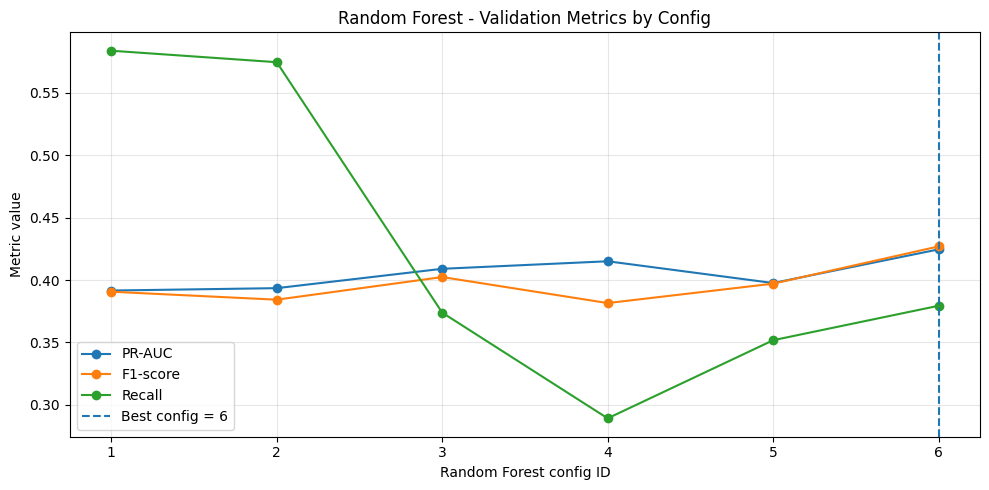

In [73]:
# 17.4. Vẽ PR-AUC, F1-score và Recall của các cấu hình Random Forest

# Vẽ theo config_id gốc để dễ đối chiếu với grid ban đầu.
rf_plot_df = rf_results_df.sort_values("config_id").reset_index(drop=True)

plt.figure(figsize=(10, 5))

plt.plot(rf_plot_df["config_id"], rf_plot_df["pr_auc"], marker="o", label="PR-AUC")

plt.plot(rf_plot_df["config_id"], rf_plot_df["f1_score"], marker="o", label="F1-score")

plt.plot(rf_plot_df["config_id"], rf_plot_df["recall"], marker="o", label="Recall")

plt.axvline(
    rf_best_config_id, linestyle="--", label=f"Best config = {rf_best_config_id}"
)

plt.xlabel("Random Forest config ID")
plt.ylabel("Metric value")
plt.title("Random Forest - Validation Metrics by Config")
plt.xticks(rf_plot_df["config_id"])
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [74]:
# 17.5. Threshold tuning cho best Random Forest trên validation set

rf_thresholds = np.arange(0.05, 0.96, 0.01)

rf_threshold_result_rows = []

for threshold in rf_thresholds:
    result_row = collect_result_row(
        model_name="Random Forest Classifier",
        split_name="Validation",
        y_true=y_val,
        y_prob=y_val_prob_rf_best,
        threshold=threshold,
    )

    rf_threshold_result_rows.append(result_row)


rf_threshold_results_df = pd.DataFrame(rf_threshold_result_rows)

rf_threshold_results_df = rf_threshold_results_df[
    [
        "model",
        "split",
        "threshold",
        "accuracy",
        "precision",
        "recall",
        "f1_score",
        "roc_auc",
        "pr_auc",
    ]
]

rf_threshold_results_df.head()

,model,split,threshold,accuracy,precision,recall,f1_score,roc_auc,pr_auc
0,Random Forest Classifier,Validation,0.05,0.215544,0.097336,0.988950,0.177228,0.823163,0.424562
1,Random Forest Classifier,Validation,0.06,0.252675,0.101534,0.987109,0.184129,0.823163,0.424562
2,Random Forest Classifier,Validation,0.07,0.286029,0.104847,0.976059,0.189353,0.823163,0.424562
3,Random Forest Classifier,Validation,0.08,0.316709,0.108247,0.966851,0.194697,0.823163,0.424562
4,Random Forest Classifier,Validation,0.09,0.351007,0.112673,0.959484,0.201664,0.823163,0.424562


In [75]:
# 17.6. Tìm Best F1 threshold cho Random Forest

# Nếu nhiều threshold có cùng F1-score, ưu tiên recall cao hơn,
# sau đó precision cao hơn.
rf_best_f1_row = (
    rf_threshold_results_df.sort_values(
        by=["f1_score", "recall", "precision"], ascending=[False, False, False]
    )
    .iloc[0]
    .to_dict()
)

rf_best_f1_threshold = rf_best_f1_row["threshold"]

print("Random Forest - Best F1 threshold trên validation set")
print(f"Threshold : {rf_best_f1_threshold:.2f}")
print(f"Precision : {rf_best_f1_row['precision']:.6f}")
print(f"Recall    : {rf_best_f1_row['recall']:.6f}")
print(f"F1-score  : {rf_best_f1_row['f1_score']:.6f}")
print(f"PR-AUC    : {rf_best_f1_row['pr_auc']:.6f}")
print(f"ROC-AUC   : {rf_best_f1_row['roc_auc']:.6f}")

Random Forest - Best F1 threshold trên validation set
Threshold : 0.47
Precision : 0.470707
Recall    : 0.429098
F1-score  : 0.448940
PR-AUC    : 0.424562
ROC-AUC   : 0.823163


In [76]:
# 17.7. Tìm Recall-prioritized threshold cho Random Forest

# Chiến lược:
# - Nếu tồn tại threshold có recall >= 0.60:
#     chọn threshold có f1_score cao nhất trong nhóm đó.
# - Nếu không tồn tại:
#     chọn threshold có recall cao nhất, sau đó f1_score cao nhất.
rf_recall_target = 0.60

rf_recall_candidate_df = rf_threshold_results_df[
    rf_threshold_results_df["recall"] >= rf_recall_target
].copy()

if len(rf_recall_candidate_df) > 0:
    rf_recall_priority_row = (
        rf_recall_candidate_df.sort_values(
            by=["f1_score", "precision", "recall"], ascending=[False, False, False]
        )
        .iloc[0]
        .to_dict()
    )

    print(f"Tìm thấy threshold Random Forest đạt recall >= {rf_recall_target:.2f}.")
    print("Chọn threshold có F1-score cao nhất trong nhóm này.")

else:
    rf_recall_priority_row = (
        rf_threshold_results_df.sort_values(
            by=["recall", "f1_score", "precision"], ascending=[False, False, False]
        )
        .iloc[0]
        .to_dict()
    )

    print(f"Không có threshold Random Forest nào đạt recall >= {rf_recall_target:.2f}.")
    print("Chọn threshold có Recall cao nhất, sau đó F1-score cao nhất.")


rf_recall_priority_threshold = rf_recall_priority_row["threshold"]

print("\nRandom Forest - Recall-prioritized threshold trên validation set")
print(f"Threshold : {rf_recall_priority_threshold:.2f}")
print(f"Precision : {rf_recall_priority_row['precision']:.6f}")
print(f"Recall    : {rf_recall_priority_row['recall']:.6f}")
print(f"F1-score  : {rf_recall_priority_row['f1_score']:.6f}")
print(f"PR-AUC    : {rf_recall_priority_row['pr_auc']:.6f}")
print(f"ROC-AUC   : {rf_recall_priority_row['roc_auc']:.6f}")

Tìm thấy threshold Random Forest đạt recall >= 0.60.
Chọn threshold có F1-score cao nhất trong nhóm này.

Random Forest - Recall-prioritized threshold trên validation set
Threshold : 0.33
Precision : 0.290464
Recall    : 0.611418
F1-score  : 0.393832
PR-AUC    : 0.424562
ROC-AUC   : 0.823163


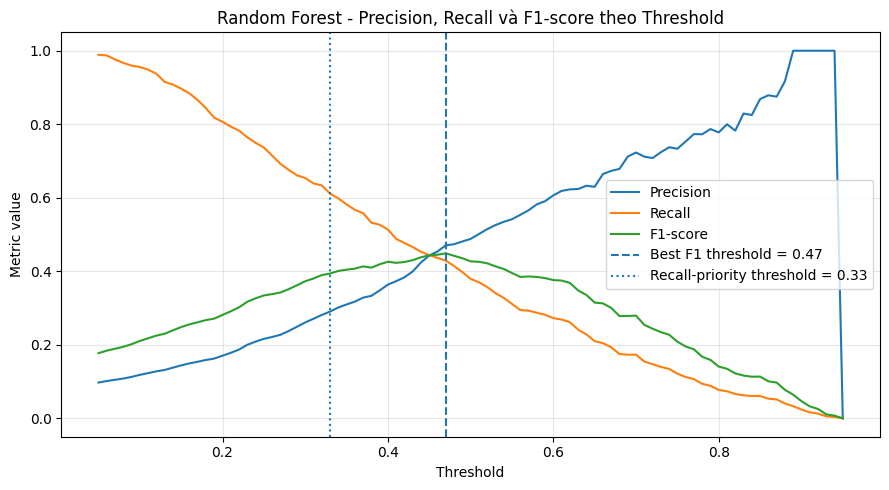

In [77]:
# 17.8. Vẽ Precision, Recall và F1-score theo threshold trên validation set

plt.figure(figsize=(9, 5))

plt.plot(
    rf_threshold_results_df["threshold"],
    rf_threshold_results_df["precision"],
    label="Precision",
)

plt.plot(
    rf_threshold_results_df["threshold"],
    rf_threshold_results_df["recall"],
    label="Recall",
)

plt.plot(
    rf_threshold_results_df["threshold"],
    rf_threshold_results_df["f1_score"],
    label="F1-score",
)

plt.axvline(
    rf_best_f1_threshold,
    linestyle="--",
    label=f"Best F1 threshold = {rf_best_f1_threshold:.2f}",
)

plt.axvline(
    rf_recall_priority_threshold,
    linestyle=":",
    label=f"Recall-priority threshold = {rf_recall_priority_threshold:.2f}",
)

plt.xlabel("Threshold")
plt.ylabel("Metric value")
plt.title("Random Forest - Precision, Recall và F1-score theo Threshold")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [78]:
# 17.9. Evaluate Random Forest trên test set với 3 threshold

# Không dùng test set để chọn threshold.
# Các threshold dưới đây đã được chọn từ validation set.
rf_test_default_row = collect_result_row(
    model_name="Random Forest Classifier",
    split_name="Test",
    y_true=y_test,
    y_prob=y_test_prob_rf_best,
    threshold=0.5,
)

rf_test_best_f1_row = collect_result_row(
    model_name="Random Forest Classifier",
    split_name="Test",
    y_true=y_test,
    y_prob=y_test_prob_rf_best,
    threshold=rf_best_f1_threshold,
)

rf_test_recall_priority_row = collect_result_row(
    model_name="Random Forest Classifier",
    split_name="Test",
    y_true=y_test,
    y_prob=y_test_prob_rf_best,
    threshold=rf_recall_priority_threshold,
)

rf_test_results_df = pd.DataFrame(
    [
        {"setting": "Random Forest default threshold = 0.5", **rf_test_default_row},
        {"setting": "Random Forest Best F1 threshold", **rf_test_best_f1_row},
        {
            "setting": "Random Forest Recall-prioritized threshold",
            **rf_test_recall_priority_row,
        },
    ]
)

rf_test_results_df = rf_test_results_df[
    [
        "setting",
        "model",
        "split",
        "threshold",
        "accuracy",
        "precision",
        "recall",
        "f1_score",
        "roc_auc",
        "pr_auc",
    ]
]

rf_test_results_df

,setting,model,split,threshold,accuracy,precision,recall,f1_score,roc_auc,pr_auc
0,Random Forest default threshold = 0.5,Random Forest Classifier,Test,0.50,0.902140,0.409910,0.335793,0.369168,0.808076,0.364441
1,Random Forest Best F1 threshold,Random Forest Classifier,Test,0.47,0.897420,0.397388,0.392989,0.395176,0.808076,0.364441
2,Random Forest Recall-prioritized threshold,Random Forest Classifier,Test,0.33,0.829452,0.272269,0.597786,0.374134,0.808076,0.364441


In [79]:
# 17.10. Tạo prediction variables trên test set

y_test_pred_rf_best_f1 = get_predictions_at_threshold(
    y_prob=y_test_prob_rf_best, threshold=rf_best_f1_threshold
)

y_test_pred_rf_recall_priority = get_predictions_at_threshold(
    y_prob=y_test_prob_rf_best, threshold=rf_recall_priority_threshold
)

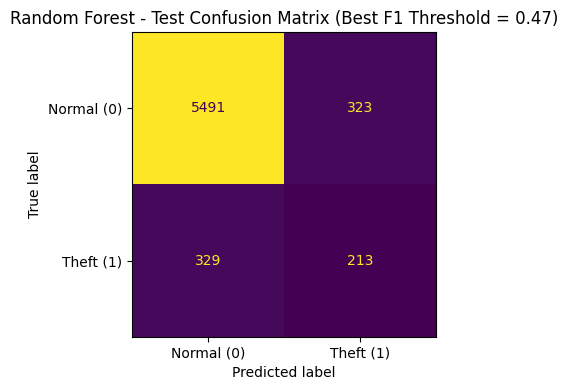

In [80]:
# 17.11. Confusion matrix trên test set với Random Forest Best F1 threshold

rf_test_best_f1_cm = plot_confusion_matrix_custom(
    y_true=y_test,
    y_pred=y_test_pred_rf_best_f1,
    title=(
        "Random Forest - Test Confusion Matrix "
        f"(Best F1 Threshold = {rf_best_f1_threshold:.2f})"
    ),
)

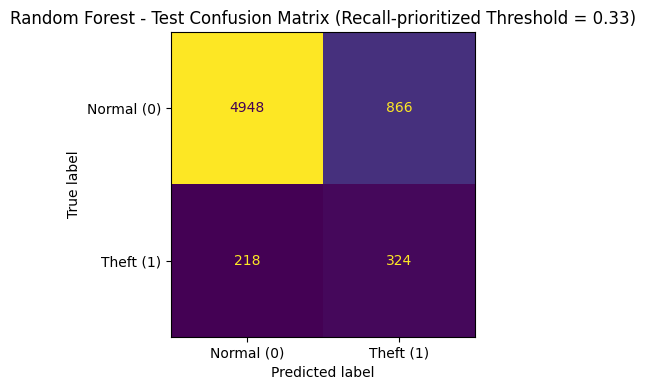

In [81]:
# 17.12. Confusion matrix trên test set với Random Forest Recall-prioritized threshold

rf_test_recall_priority_cm = plot_confusion_matrix_custom(
    y_true=y_test,
    y_pred=y_test_pred_rf_recall_priority,
    title=(
        "Random Forest - Test Confusion Matrix "
        f"(Recall-prioritized Threshold = {rf_recall_priority_threshold:.2f})"
    ),
)

In [82]:
# 17.13. So sánh Random Forest với Logistic Regression L2 thường và Weighted Logistic Regression

# Các biến từ bước trước:
# - test_best_f1_row, test_recall_priority_row:
#     Logistic Regression L2 thường từ STEP 12
# - weighted_test_best_f1_row, weighted_test_recall_priority_row:
#     Weighted Logistic Regression từ STEP 16
# - rf_test_best_f1_row, rf_test_recall_priority_row:
#     Random Forest từ STEP 17
rf_vs_logreg_comparison_df = pd.DataFrame(
    [
        {
            "comparison_setting": "Logistic Regression L2 - Best F1 threshold",
            **test_best_f1_row,
        },
        {
            "comparison_setting": "Weighted Logistic Regression - Best F1 threshold",
            **weighted_test_best_f1_row,
        },
        {
            "comparison_setting": "Random Forest - Best F1 threshold",
            **rf_test_best_f1_row,
        },
        {
            "comparison_setting": "Logistic Regression L2 - Recall-prioritized threshold",
            **test_recall_priority_row,
        },
        {
            "comparison_setting": "Weighted Logistic Regression - Recall-prioritized threshold",
            **weighted_test_recall_priority_row,
        },
        {
            "comparison_setting": "Random Forest - Recall-prioritized threshold",
            **rf_test_recall_priority_row,
        },
    ]
)

rf_vs_logreg_comparison_df = rf_vs_logreg_comparison_df[
    [
        "comparison_setting",
        "model",
        "split",
        "threshold",
        "accuracy",
        "precision",
        "recall",
        "f1_score",
        "roc_auc",
        "pr_auc",
    ]
]

rf_vs_logreg_comparison_df

,comparison_setting,model,split,threshold,accuracy,precision,recall,f1_score,roc_auc,pr_auc
0,Logistic Regression L2 - Best F1 threshold,Logistic Regression L2 (C=100.0),Test,0.16,0.871145,0.303546,0.394834,0.343224,0.773105,0.311792
1,Weighted Logistic Regression - Best F1 threshold,Weighted Logistic Regression L2 (C=100.0),Test,0.70,0.880113,0.322581,0.369004,0.344234,0.774308,0.308545
2,Random Forest - Best F1 threshold,Random Forest Classifier,Test,0.47,0.897420,0.397388,0.392989,0.395176,0.808076,0.364441
3,Logistic Regression L2 - Recall-prioritized th...,Logistic Regression L2 (C=100.0),Test,0.11,0.797514,0.224686,0.560886,0.320844,0.773105,0.311792
4,Weighted Logistic Regression - Recall-prioriti...,Weighted Logistic Regression L2 (C=100.0),Test,0.56,0.803021,0.225657,0.538745,0.318083,0.774308,0.308545
5,Random Forest - Recall-prioritized threshold,Random Forest Classifier,Test,0.33,0.829452,0.272269,0.597786,0.374134,0.808076,0.364441


### Nhận xét

+ Kết quả STEP 17 cho thấy Random Forest cải thiện rõ rệt so với Logistic Regression family trên cả validation set và test set. Điều này cho thấy các quan hệ phi tuyến và interaction giữa các feature có vai trò quan trọng trong bài toán phát hiện trộm điện.

+ Trên validation set, cấu hình Random Forest tốt nhất là `n_estimators = 300`, `max_depth = None`, `min_samples_leaf = 10`, `max_features = "sqrt"` và `class_weight = "balanced_subsample"`. Cấu hình này đạt PR-AUC = 0.4246, ROC-AUC = 0.8232 và F1-score = 0.4269 tại threshold mặc định 0.5. So với Logistic Regression L2, Random Forest có PR-AUC và ROC-AUC cao hơn rõ rệt, cho thấy khả năng ranking theft customers tốt hơn.

+ Trên test set tại Best F1 threshold, Random Forest đạt F1-score = 0.3952, cao hơn Logistic Regression L2 thường với F1-score = 0.3432 và Weighted Logistic Regression với F1-score = 0.3442. Đặc biệt, Random Forest đạt Precision = 0.3974 trong khi vẫn giữ Recall = 0.3930, cho thấy model giảm đáng kể số False Positive mà không làm mất nhiều khả năng phát hiện theft.

+ Confusion Matrix cũng cho thấy cải thiện rõ ràng. Ở Best F1 threshold, Random Forest phát hiện gần như cùng số theft customers so với Logistic Regression L2, nhưng giảm số False Positive từ 491 xuống 323. Điều này giúp model thực tế hơn vì giảm số lượng khách hàng normal bị cảnh báo nhầm.

+ Ở Recall-prioritized threshold, Random Forest tiếp tục cho kết quả tốt hơn Logistic Regression L2. Random Forest đạt Recall = 0.5978 và F1-score = 0.3741, đồng thời có Precision = 0.2723. So với Logistic Regression L2 recall-prioritized, Random Forest vừa phát hiện thêm theft customers, vừa giảm số False Positive. Điều này cho thấy Random Forest không chỉ tăng Recall bằng cách dự đoán theft nhiều hơn, mà thật sự cải thiện khả năng phân biệt giữa normal và theft.

+ Kết quả này cho thấy Logistic Regression family, dù phù hợp và dễ giải thích, có thể bị giới hạn bởi giả định tuyến tính. Trong khi đó, Random Forest có khả năng học các quan hệ phi tuyến và interaction phức tạp giữa các feature như zero ratio, drop pattern, volatility, rolling statistics và quality features. Vì vậy, Random Forest hiện là model có hiệu năng tốt nhất trong các model đã thử.

+ Tuy nhiên, F1-score của Random Forest vẫn chưa đủ cao để dùng model như một hệ thống tự động kết luận trộm điện trong thực tế. Model nên được hiểu là công cụ hỗ trợ ranking rủi ro hoặc đề xuất danh sách khách hàng cần kiểm tra, thay vì thay thế hoàn toàn quá trình điều tra thực tế.

## 18. LightGBM Classifier

Ở STEP 17, Random Forest đã cải thiện rõ so với Logistic Regression family. Điều này cho thấy các quan hệ phi tuyến và interaction giữa feature là quan trọng trong bài toán Energy Theft Detection.

Trong STEP 18, ta thử **LightGBM Classifier** như một model thuộc nhóm **Gradient Boosting**.

LightGBM là một Gradient Boosting model mạnh cho tabular data. Thay vì train nhiều cây độc lập như Random Forest, LightGBM train các cây theo tuần tự. Mỗi cây mới cố gắng sửa lỗi của các cây trước đó. Vì vậy, LightGBM thường có khả năng học pattern phức tạp tốt hơn Random Forest trong nhiều bài toán dữ liệu bảng.

Khác biệt chính giữa Random Forest và Gradient Boosting:

- **Random Forest**: train nhiều Decision Tree tương đối độc lập rồi ensemble kết quả. Đây là hướng bagging.
- **LightGBM / Gradient Boosting**: train cây tuần tự, mỗi cây sau tập trung cải thiện phần lỗi còn lại của ensemble trước đó.

LightGBM có thể mạnh hơn Random Forest trên tabular data vì:

- Học được quan hệ phi tuyến.
- Học được interaction phức tạp giữa feature.
- Tối ưu loss theo hướng boosting tuần tự.
- Có nhiều cơ chế regularization như `num_leaves`, `max_depth`, `min_child_samples`, `subsample`, `colsample_bytree`.

Vì dataset bị mất cân bằng, ta dùng `scale_pos_weight`:

$$
scale\_pos\_weight = \frac{\text{số mẫu class 0 trong train}}{\text{số mẫu class 1 trong train}}
$$

Tham số này giúp LightGBM tăng trọng số cho class minority, tức class `1 = theft`, trong quá trình training.

Tuy nhiên, sau khi dùng `scale_pos_weight`, ta vẫn cần threshold tuning vì:

- `scale_pos_weight` ảnh hưởng quá trình học model.
- Threshold ảnh hưởng cách chuyển xác suất thành nhãn `0/1`.
- Threshold mặc định `0.5` chưa chắc tối ưu cho Recall hoặc F1-score trong imbalanced dataset.

Trong STEP này:

- Validation set được dùng để chọn hyperparameter và threshold.
- Test set chỉ dùng sau khi model và threshold đã được chọn.
- Không dùng test set để chọn hyperparameter.
- Không dùng test set để chọn threshold.
- Không dùng Negative Sampling hoặc Oversampling.
- Không dùng XGBoost hoặc CatBoost trong STEP này.
- Không dùng GridSearchCV, RandomizedSearchCV hoặc Cross-Validation.

Ta chỉ dùng manual validation search với một số cấu hình đại diện để giữ pipeline đơn giản, nhất quán với các bước trước, dễ so sánh và tránh over-engineering.

Nếu LightGBM in warning trong quá trình train, nhiều warning có thể chỉ là thông báo nội bộ của LightGBM, ví dụ không tìm được split cải thiện thêm. Nếu training vẫn hoàn tất và metrics được tính bình thường, warning đó thường không ảnh hưởng nghiêm trọng đến bước so sánh model.

In [83]:
# STEP 18: LightGBM Classifier

import time

try:
    from lightgbm import LGBMClassifier
except ImportError as error:
    raise ImportError(
        "Không thể import LightGBM. " "Vui lòng cài đặt bằng lệnh: pip install lightgbm"
    ) from error

In [84]:
# 18.1. Tính scale_pos_weight từ train set

# scale_pos_weight = số mẫu class 0 / số mẫu class 1
# Chỉ tính trên train set để tránh data leakage.
y_train_series = pd.Series(y_train)

train_class_counts = y_train_series.value_counts().sort_index()

n_negative = train_class_counts.loc[0]
n_positive = train_class_counts.loc[1]

scale_pos_weight = n_negative / n_positive

print("Train class distribution:")
print(train_class_counts)

print("\nTrain class ratio:")
print((train_class_counts / train_class_counts.sum()).round(6))

print(f"\nscale_pos_weight = {scale_pos_weight:.6f}")

Train class distribution:
FLAG
0    27130
1     2530
Name: count, dtype: int64

Train class ratio:
FLAG
0    0.9147
1    0.0853
Name: count, dtype: float64

scale_pos_weight = 10.723320


In [85]:
# 18.2. Manual validation search cho LightGBM

lgbm_param_grid = [
    {
        "n_estimators": 200,
        "learning_rate": 0.05,
        "num_leaves": 31,
        "max_depth": -1,
        "min_child_samples": 20,
        "subsample": 0.8,
        "colsample_bytree": 0.8,
    },
    {
        "n_estimators": 400,
        "learning_rate": 0.03,
        "num_leaves": 31,
        "max_depth": -1,
        "min_child_samples": 20,
        "subsample": 0.8,
        "colsample_bytree": 0.8,
    },
    {
        "n_estimators": 400,
        "learning_rate": 0.03,
        "num_leaves": 63,
        "max_depth": -1,
        "min_child_samples": 30,
        "subsample": 0.8,
        "colsample_bytree": 0.8,
    },
    {
        "n_estimators": 600,
        "learning_rate": 0.02,
        "num_leaves": 31,
        "max_depth": -1,
        "min_child_samples": 30,
        "subsample": 0.8,
        "colsample_bytree": 0.8,
    },
    {
        "n_estimators": 400,
        "learning_rate": 0.03,
        "num_leaves": 31,
        "max_depth": 8,
        "min_child_samples": 20,
        "subsample": 0.9,
        "colsample_bytree": 0.9,
    },
    {
        "n_estimators": 600,
        "learning_rate": 0.02,
        "num_leaves": 63,
        "max_depth": 10,
        "min_child_samples": 40,
        "subsample": 0.9,
        "colsample_bytree": 0.9,
    },
]

lgbm_result_rows = []
lgbm_models = {}
lgbm_val_probabilities = {}

lgbm_default_threshold = 0.5


for config_id, params in enumerate(lgbm_param_grid, start=1):
    print("=" * 80)
    print(f"Training LightGBM config {config_id}/{len(lgbm_param_grid)}")
    print(params)

    start_time = time.time()

    lgbm_model = LGBMClassifier(
        objective="binary",
        n_estimators=params["n_estimators"],
        learning_rate=params["learning_rate"],
        num_leaves=params["num_leaves"],
        max_depth=params["max_depth"],
        min_child_samples=params["min_child_samples"],
        subsample=params["subsample"],
        colsample_bytree=params["colsample_bytree"],
        scale_pos_weight=scale_pos_weight,
        random_state=RANDOM_STATE,
        n_jobs=-1,
        verbosity=-1,
    )

    # Train chỉ trên train set.
    # Không dùng validation hoặc test trong quá trình fit.
    lgbm_model.fit(X_train_scaled, y_train)

    runtime_seconds = time.time() - start_time

    # Predict probability class 1 = theft trên validation set.
    y_val_prob_lgbm = lgbm_model.predict_proba(X_val_scaled)[:, 1]

    model_name = (
        "LightGBM "
        f"(n={params['n_estimators']}, "
        f"lr={params['learning_rate']}, "
        f"leaves={params['num_leaves']}, "
        f"depth={params['max_depth']})"
    )

    result_row = collect_result_row(
        model_name=model_name,
        split_name="Validation",
        y_true=y_val,
        y_prob=y_val_prob_lgbm,
        threshold=lgbm_default_threshold,
    )

    # Lưu thêm hyperparameter và thời gian chạy.
    result_row["config_id"] = config_id
    result_row["n_estimators"] = params["n_estimators"]
    result_row["learning_rate"] = params["learning_rate"]
    result_row["num_leaves"] = params["num_leaves"]
    result_row["max_depth"] = params["max_depth"]
    result_row["min_child_samples"] = params["min_child_samples"]
    result_row["subsample"] = params["subsample"]
    result_row["colsample_bytree"] = params["colsample_bytree"]
    result_row["scale_pos_weight"] = scale_pos_weight
    result_row["runtime_seconds"] = runtime_seconds

    lgbm_result_rows.append(result_row)

    lgbm_models[config_id] = lgbm_model
    lgbm_val_probabilities[config_id] = y_val_prob_lgbm

    print(f"Done config {config_id}/{len(lgbm_param_grid)}")
    print(f"Runtime seconds   : {runtime_seconds:.2f}")
    print(f"Validation PR-AUC : {result_row['pr_auc']:.6f}")
    print(f"Validation F1     : {result_row['f1_score']:.6f}")
    print(f"Validation Recall : {result_row['recall']:.6f}")


lgbm_results_df = pd.DataFrame(lgbm_result_rows)

# Sắp xếp theo thứ tự ưu tiên:
# 1. pr_auc giảm dần
# 2. f1_score giảm dần
# 3. recall giảm dần
lgbm_results_df = lgbm_results_df.sort_values(
    by=["pr_auc", "f1_score", "recall"], ascending=[False, False, False]
).reset_index(drop=True)

lgbm_results_df = lgbm_results_df[
    [
        "config_id",
        "model",
        "split",
        "threshold",
        "accuracy",
        "precision",
        "recall",
        "f1_score",
        "roc_auc",
        "pr_auc",
        "n_estimators",
        "learning_rate",
        "num_leaves",
        "max_depth",
        "min_child_samples",
        "subsample",
        "colsample_bytree",
        "scale_pos_weight",
        "runtime_seconds",
    ]
]

lgbm_results_df

Training LightGBM config 1/6
{'n_estimators': 200, 'learning_rate': 0.05, 'num_leaves': 31, 'max_depth': -1, 'min_child_samples': 20, 'subsample': 0.8, 'colsample_bytree': 0.8}
Done config 1/6
Runtime seconds   : 0.72
Validation PR-AUC : 0.485695
Validation F1     : 0.428660
Validation Recall : 0.633517
Training LightGBM config 2/6
{'n_estimators': 400, 'learning_rate': 0.03, 'num_leaves': 31, 'max_depth': -1, 'min_child_samples': 20, 'subsample': 0.8, 'colsample_bytree': 0.8}
Done config 2/6
Runtime seconds   : 1.09
Validation PR-AUC : 0.493955
Validation F1     : 0.434263
Validation Recall : 0.602210
Training LightGBM config 3/6
{'n_estimators': 400, 'learning_rate': 0.03, 'num_leaves': 63, 'max_depth': -1, 'min_child_samples': 30, 'subsample': 0.8, 'colsample_bytree': 0.8}
Done config 3/6
Runtime seconds   : 1.86
Validation PR-AUC : 0.512381
Validation F1     : 0.477485
Validation Recall : 0.517495
Training LightGBM config 4/6
{'n_estimators': 600, 'learning_rate': 0.02, 'num_leaves

,config_id,model,split,threshold,accuracy,precision,recall,f1_score,roc_auc,pr_auc,n_estimators,learning_rate,num_leaves,max_depth,min_child_samples,subsample,colsample_bytree,scale_pos_weight,runtime_seconds
0,3,"LightGBM (n=400, lr=0.03, leaves=63, depth=-1)",Validation,0.5,0.903241,0.443218,0.517495,0.477485,0.842003,0.512381,400,0.03,63,-1,30,0.8,0.8,10.72332,1.855475
1,6,"LightGBM (n=600, lr=0.02, leaves=63, depth=10)",Validation,0.5,0.899150,0.426647,0.524862,0.470685,0.836750,0.504926,600,0.02,63,10,40,0.9,0.9,10.72332,2.664694
2,4,"LightGBM (n=600, lr=0.02, leaves=31, depth=-1)",Validation,0.5,0.867841,0.347379,0.622468,0.445910,0.842989,0.495781,600,0.02,31,-1,30,0.8,0.8,10.72332,1.577791
3,2,"LightGBM (n=400, lr=0.03, leaves=31, depth=-1)",Validation,0.5,0.865953,0.339564,0.602210,0.434263,0.843822,0.493955,400,0.03,31,-1,20,0.8,0.8,10.72332,1.091011
4,5,"LightGBM (n=400, lr=0.03, leaves=31, depth=8)",Validation,0.5,0.862335,0.334331,0.616943,0.433657,0.842599,0.492726,400,0.03,31,8,20,0.9,0.9,10.72332,1.057226
5,1,"LightGBM (n=200, lr=0.05, leaves=31, depth=-1)",Validation,0.5,0.855727,0.323917,0.633517,0.428660,0.843132,0.485695,200,0.05,31,-1,20,0.8,0.8,10.72332,0.722178


In [86]:
# 18.3. Chọn best LightGBM model trên validation set

lgbm_best_row = lgbm_results_df.iloc[0].to_dict()

lgbm_best_config_id = int(lgbm_best_row["config_id"])
lgbm_best_model = lgbm_models[lgbm_best_config_id]
y_val_prob_lgbm_best = lgbm_val_probabilities[lgbm_best_config_id]

lgbm_best_params = {
    "n_estimators": lgbm_best_row["n_estimators"],
    "learning_rate": lgbm_best_row["learning_rate"],
    "num_leaves": lgbm_best_row["num_leaves"],
    "max_depth": lgbm_best_row["max_depth"],
    "min_child_samples": lgbm_best_row["min_child_samples"],
    "subsample": lgbm_best_row["subsample"],
    "colsample_bytree": lgbm_best_row["colsample_bytree"],
    "scale_pos_weight": lgbm_best_row["scale_pos_weight"],
}

# Predict probability trên test set chỉ sau khi best LightGBM đã được chọn từ validation set.
# Không dùng test set để chọn hyperparameter.
y_test_prob_lgbm_best = lgbm_best_model.predict_proba(X_test_scaled)[:, 1]

print("Best LightGBM trên validation set")
print(f"Config ID        : {lgbm_best_config_id}")
print(f"Best params      : {lgbm_best_params}")
print(f"PR-AUC           : {lgbm_best_row['pr_auc']:.6f}")
print(f"F1-score         : {lgbm_best_row['f1_score']:.6f}")
print(f"Recall           : {lgbm_best_row['recall']:.6f}")
print(f"Precision        : {lgbm_best_row['precision']:.6f}")
print(f"Accuracy         : {lgbm_best_row['accuracy']:.6f}")
print(f"ROC-AUC          : {lgbm_best_row['roc_auc']:.6f}")
print(f"Runtime seconds  : {lgbm_best_row['runtime_seconds']:.2f}")

Best LightGBM trên validation set
Config ID        : 3
Best params      : {'n_estimators': 400, 'learning_rate': 0.03, 'num_leaves': 63, 'max_depth': -1, 'min_child_samples': 30, 'subsample': 0.8, 'colsample_bytree': 0.8, 'scale_pos_weight': 10.723320158102768}
PR-AUC           : 0.512381
F1-score         : 0.477485
Recall           : 0.517495
Precision        : 0.443218
Accuracy         : 0.903241
ROC-AUC          : 0.842003
Runtime seconds  : 1.86


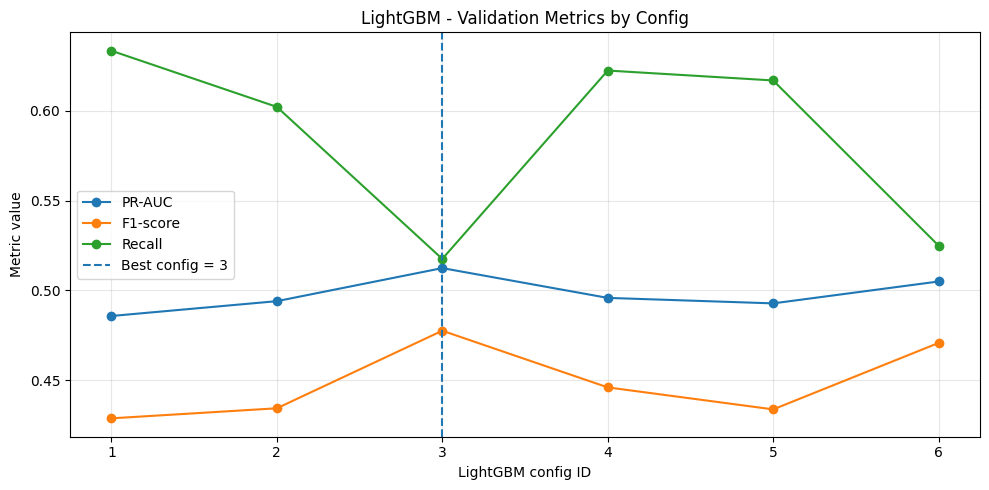

In [87]:
# 18.4. Vẽ PR-AUC, F1-score và Recall của các cấu hình LightGBM

# Vẽ theo config_id gốc để dễ đối chiếu với grid ban đầu.
lgbm_plot_df = lgbm_results_df.sort_values("config_id").reset_index(drop=True)

plt.figure(figsize=(10, 5))

plt.plot(lgbm_plot_df["config_id"], lgbm_plot_df["pr_auc"], marker="o", label="PR-AUC")

plt.plot(
    lgbm_plot_df["config_id"], lgbm_plot_df["f1_score"], marker="o", label="F1-score"
)

plt.plot(lgbm_plot_df["config_id"], lgbm_plot_df["recall"], marker="o", label="Recall")

plt.axvline(
    lgbm_best_config_id, linestyle="--", label=f"Best config = {lgbm_best_config_id}"
)

plt.xlabel("LightGBM config ID")
plt.ylabel("Metric value")
plt.title("LightGBM - Validation Metrics by Config")
plt.xticks(lgbm_plot_df["config_id"])
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [88]:
# 18.5. Threshold tuning cho best LightGBM trên validation set

lgbm_thresholds = np.arange(0.05, 0.96, 0.01)

lgbm_threshold_result_rows = []

for threshold in lgbm_thresholds:
    result_row = collect_result_row(
        model_name="LightGBM Classifier",
        split_name="Validation",
        y_true=y_val,
        y_prob=y_val_prob_lgbm_best,
        threshold=threshold,
    )

    lgbm_threshold_result_rows.append(result_row)


lgbm_threshold_results_df = pd.DataFrame(lgbm_threshold_result_rows)

lgbm_threshold_results_df = lgbm_threshold_results_df[
    [
        "model",
        "split",
        "threshold",
        "accuracy",
        "precision",
        "recall",
        "f1_score",
        "roc_auc",
        "pr_auc",
    ]
]

lgbm_threshold_results_df.head()

,model,split,threshold,accuracy,precision,recall,f1_score,roc_auc,pr_auc
0,LightGBM Classifier,Validation,0.05,0.377911,0.115792,0.946593,0.206343,0.842003,0.512381
1,LightGBM Classifier,Validation,0.06,0.421649,0.122257,0.933702,0.216205,0.842003,0.512381
2,LightGBM Classifier,Validation,0.07,0.458622,0.128842,0.926335,0.226220,0.842003,0.512381
3,LightGBM Classifier,Validation,0.08,0.487728,0.133873,0.913444,0.233522,0.842003,0.512381
4,LightGBM Classifier,Validation,0.09,0.520453,0.141426,0.909761,0.244797,0.842003,0.512381


In [89]:
# 18.6. Tìm Best F1 threshold cho LightGBM

# Nếu nhiều threshold có cùng F1-score, ưu tiên recall cao hơn,
# sau đó precision cao hơn.
lgbm_best_f1_row = (
    lgbm_threshold_results_df.sort_values(
        by=["f1_score", "recall", "precision"], ascending=[False, False, False]
    )
    .iloc[0]
    .to_dict()
)

lgbm_best_f1_threshold = lgbm_best_f1_row["threshold"]

print("LightGBM - Best F1 threshold trên validation set")
print(f"Threshold : {lgbm_best_f1_threshold:.2f}")
print(f"Precision : {lgbm_best_f1_row['precision']:.6f}")
print(f"Recall    : {lgbm_best_f1_row['recall']:.6f}")
print(f"F1-score  : {lgbm_best_f1_row['f1_score']:.6f}")
print(f"PR-AUC    : {lgbm_best_f1_row['pr_auc']:.6f}")
print(f"ROC-AUC   : {lgbm_best_f1_row['roc_auc']:.6f}")

LightGBM - Best F1 threshold trên validation set
Threshold : 0.59
Precision : 0.554810
Recall    : 0.456722
F1-score  : 0.501010
PR-AUC    : 0.512381
ROC-AUC   : 0.842003


In [90]:
# 18.7. Tìm Recall-prioritized threshold cho LightGBM

# Chiến lược:
# - Nếu tồn tại threshold có recall >= 0.60:
#     chọn threshold có f1_score cao nhất trong nhóm đó.
# - Nếu không tồn tại:
#     chọn threshold có recall cao nhất, sau đó f1_score cao nhất.
lgbm_recall_target = 0.60

lgbm_recall_candidate_df = lgbm_threshold_results_df[
    lgbm_threshold_results_df["recall"] >= lgbm_recall_target
].copy()

if len(lgbm_recall_candidate_df) > 0:
    lgbm_recall_priority_row = (
        lgbm_recall_candidate_df.sort_values(
            by=["f1_score", "precision", "recall"], ascending=[False, False, False]
        )
        .iloc[0]
        .to_dict()
    )

    print(f"Tìm thấy threshold LightGBM đạt recall >= {lgbm_recall_target:.2f}.")
    print("Chọn threshold có F1-score cao nhất trong nhóm này.")

else:
    lgbm_recall_priority_row = (
        lgbm_threshold_results_df.sort_values(
            by=["recall", "f1_score", "precision"], ascending=[False, False, False]
        )
        .iloc[0]
        .to_dict()
    )

    print(f"Không có threshold LightGBM nào đạt recall >= {lgbm_recall_target:.2f}.")
    print("Chọn threshold có Recall cao nhất, sau đó F1-score cao nhất.")


lgbm_recall_priority_threshold = lgbm_recall_priority_row["threshold"]

print("\nLightGBM - Recall-prioritized threshold trên validation set")
print(f"Threshold : {lgbm_recall_priority_threshold:.2f}")
print(f"Precision : {lgbm_recall_priority_row['precision']:.6f}")
print(f"Recall    : {lgbm_recall_priority_row['recall']:.6f}")
print(f"F1-score  : {lgbm_recall_priority_row['f1_score']:.6f}")
print(f"PR-AUC    : {lgbm_recall_priority_row['pr_auc']:.6f}")
print(f"ROC-AUC   : {lgbm_recall_priority_row['roc_auc']:.6f}")

Tìm thấy threshold LightGBM đạt recall >= 0.60.
Chọn threshold có F1-score cao nhất trong nhóm này.

LightGBM - Recall-prioritized threshold trên validation set
Threshold : 0.40
Precision : 0.361820
Recall    : 0.600368
F1-score  : 0.451524
PR-AUC    : 0.512381
ROC-AUC   : 0.842003


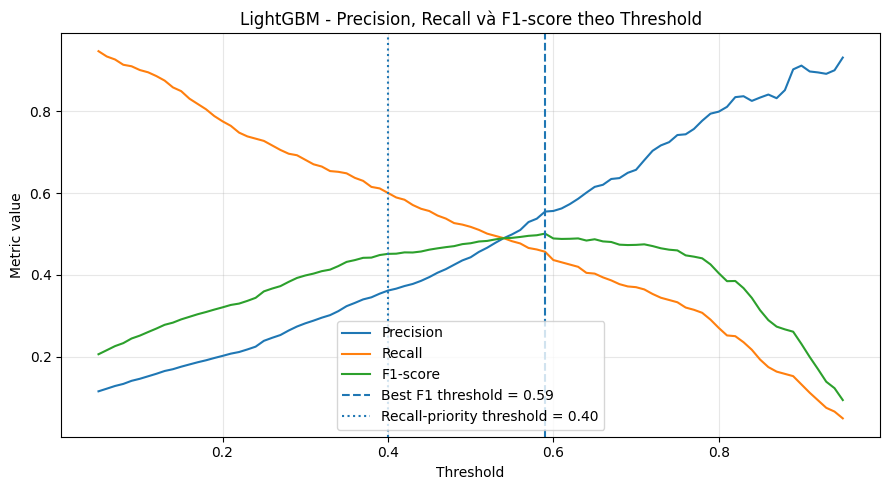

In [91]:
# 18.8. Vẽ Precision, Recall và F1-score theo threshold trên validation set

plt.figure(figsize=(9, 5))

plt.plot(
    lgbm_threshold_results_df["threshold"],
    lgbm_threshold_results_df["precision"],
    label="Precision",
)

plt.plot(
    lgbm_threshold_results_df["threshold"],
    lgbm_threshold_results_df["recall"],
    label="Recall",
)

plt.plot(
    lgbm_threshold_results_df["threshold"],
    lgbm_threshold_results_df["f1_score"],
    label="F1-score",
)

plt.axvline(
    lgbm_best_f1_threshold,
    linestyle="--",
    label=f"Best F1 threshold = {lgbm_best_f1_threshold:.2f}",
)

plt.axvline(
    lgbm_recall_priority_threshold,
    linestyle=":",
    label=f"Recall-priority threshold = {lgbm_recall_priority_threshold:.2f}",
)

plt.xlabel("Threshold")
plt.ylabel("Metric value")
plt.title("LightGBM - Precision, Recall và F1-score theo Threshold")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [92]:
# 18.9. Evaluate LightGBM trên test set với 3 threshold

# Không dùng test set để chọn threshold.
# Các threshold dưới đây đã được chọn từ validation set.
lgbm_test_default_row = collect_result_row(
    model_name="LightGBM Classifier",
    split_name="Test",
    y_true=y_test,
    y_prob=y_test_prob_lgbm_best,
    threshold=0.5,
)

lgbm_test_best_f1_row = collect_result_row(
    model_name="LightGBM Classifier",
    split_name="Test",
    y_true=y_test,
    y_prob=y_test_prob_lgbm_best,
    threshold=lgbm_best_f1_threshold,
)

lgbm_test_recall_priority_row = collect_result_row(
    model_name="LightGBM Classifier",
    split_name="Test",
    y_true=y_test,
    y_prob=y_test_prob_lgbm_best,
    threshold=lgbm_recall_priority_threshold,
)

lgbm_test_results_df = pd.DataFrame(
    [
        {"setting": "LightGBM default threshold = 0.5", **lgbm_test_default_row},
        {"setting": "LightGBM Best F1 threshold", **lgbm_test_best_f1_row},
        {
            "setting": "LightGBM Recall-prioritized threshold",
            **lgbm_test_recall_priority_row,
        },
    ]
)

lgbm_test_results_df = lgbm_test_results_df[
    [
        "setting",
        "model",
        "split",
        "threshold",
        "accuracy",
        "precision",
        "recall",
        "f1_score",
        "roc_auc",
        "pr_auc",
    ]
]

lgbm_test_results_df

,setting,model,split,threshold,accuracy,precision,recall,f1_score,roc_auc,pr_auc
0,LightGBM default threshold = 0.5,LightGBM Classifier,Test,0.50,0.895689,0.406780,0.487085,0.443325,0.836278,0.440849
1,LightGBM Best F1 threshold,LightGBM Classifier,Test,0.59,0.909692,0.465517,0.398524,0.429423,0.836278,0.440849
2,LightGBM Recall-prioritized threshold,LightGBM Classifier,Test,0.40,0.860289,0.322382,0.579336,0.414248,0.836278,0.440849


In [93]:
# 18.10. Tạo prediction variables trên test set

y_test_pred_lgbm_best_f1 = get_predictions_at_threshold(
    y_prob=y_test_prob_lgbm_best, threshold=lgbm_best_f1_threshold
)

y_test_pred_lgbm_recall_priority = get_predictions_at_threshold(
    y_prob=y_test_prob_lgbm_best, threshold=lgbm_recall_priority_threshold
)

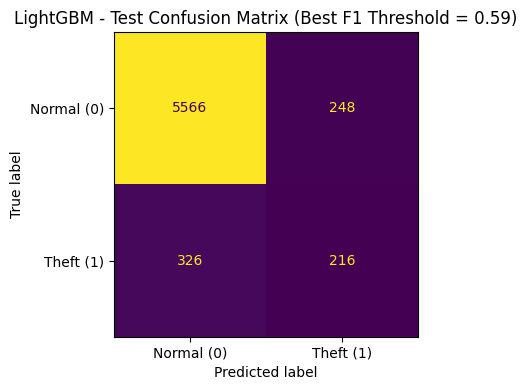

In [94]:
# 18.11. Confusion matrix trên test set với LightGBM Best F1 threshold

lgbm_test_best_f1_cm = plot_confusion_matrix_custom(
    y_true=y_test,
    y_pred=y_test_pred_lgbm_best_f1,
    title=(
        "LightGBM - Test Confusion Matrix "
        f"(Best F1 Threshold = {lgbm_best_f1_threshold:.2f})"
    ),
)

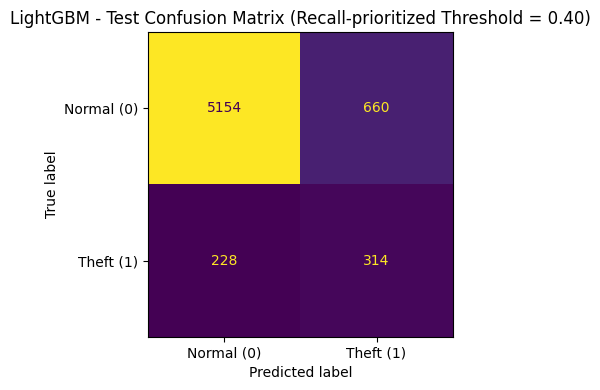

In [95]:
# 18.12. Confusion matrix trên test set với LightGBM Recall-prioritized threshold

lgbm_test_recall_priority_cm = plot_confusion_matrix_custom(
    y_true=y_test,
    y_pred=y_test_pred_lgbm_recall_priority,
    title=(
        "LightGBM - Test Confusion Matrix "
        f"(Recall-prioritized Threshold = {lgbm_recall_priority_threshold:.2f})"
    ),
)

In [96]:
# 18.13. So sánh LightGBM với Logistic Regression L2 và Random Forest trên test set

# Các biến từ bước trước:
# - test_best_f1_row, test_recall_priority_row:
#     Logistic Regression L2 thường từ STEP 12
# - rf_test_best_f1_row, rf_test_recall_priority_row:
#     Random Forest từ STEP 17
# - lgbm_test_best_f1_row, lgbm_test_recall_priority_row:
#     LightGBM từ STEP 18
lgbm_vs_previous_models_df = pd.DataFrame(
    [
        {
            "comparison_setting": "Logistic Regression L2 - Best F1 threshold",
            **test_best_f1_row,
        },
        {
            "comparison_setting": "Random Forest - Best F1 threshold",
            **rf_test_best_f1_row,
        },
        {"comparison_setting": "LightGBM - Best F1 threshold", **lgbm_test_best_f1_row},
        {
            "comparison_setting": "Logistic Regression L2 - Recall-prioritized threshold",
            **test_recall_priority_row,
        },
        {
            "comparison_setting": "Random Forest - Recall-prioritized threshold",
            **rf_test_recall_priority_row,
        },
        {
            "comparison_setting": "LightGBM - Recall-prioritized threshold",
            **lgbm_test_recall_priority_row,
        },
    ]
)

lgbm_vs_previous_models_df = lgbm_vs_previous_models_df[
    [
        "comparison_setting",
        "model",
        "split",
        "threshold",
        "accuracy",
        "precision",
        "recall",
        "f1_score",
        "roc_auc",
        "pr_auc",
    ]
]

lgbm_vs_previous_models_df

,comparison_setting,model,split,threshold,accuracy,precision,recall,f1_score,roc_auc,pr_auc
0,Logistic Regression L2 - Best F1 threshold,Logistic Regression L2 (C=100.0),Test,0.16,0.871145,0.303546,0.394834,0.343224,0.773105,0.311792
1,Random Forest - Best F1 threshold,Random Forest Classifier,Test,0.47,0.897420,0.397388,0.392989,0.395176,0.808076,0.364441
2,LightGBM - Best F1 threshold,LightGBM Classifier,Test,0.59,0.909692,0.465517,0.398524,0.429423,0.836278,0.440849
3,Logistic Regression L2 - Recall-prioritized th...,Logistic Regression L2 (C=100.0),Test,0.11,0.797514,0.224686,0.560886,0.320844,0.773105,0.311792
4,Random Forest - Recall-prioritized threshold,Random Forest Classifier,Test,0.33,0.829452,0.272269,0.597786,0.374134,0.808076,0.364441
5,LightGBM - Recall-prioritized threshold,LightGBM Classifier,Test,0.40,0.860289,0.322382,0.579336,0.414248,0.836278,0.440849


### Nhận xét

+ Kết quả STEP 18 cho thấy LightGBM cải thiện rõ rệt so với các model trước đó, bao gồm Logistic Regression L2 và Random Forest. Đây là model đầu tiên trong project đưa F1-score trên test set vượt mốc 0.4 một cách rõ ràng.

+ Trên validation set, cấu hình LightGBM tốt nhất là `n_estimators = 400`, `learning_rate = 0.03`, `num_leaves = 63`, `max_depth = -1`, `min_child_samples = 30`, `subsample = 0.8`, `colsample_bytree = 0.8`, với `scale_pos_weight = 10.7233`. Cấu hình này đạt PR-AUC = 0.5124, ROC-AUC = 0.8420 và F1-score = 0.4775 tại threshold mặc định 0.5. Sau khi tune threshold trên validation set, Best F1 threshold được chọn là 0.59.

+ Trên test set tại Best F1 threshold, LightGBM đạt F1-score = 0.4294, cao hơn Random Forest với F1-score = 0.3952 và Logistic Regression L2 với F1-score = 0.3432. LightGBM cũng đạt PR-AUC = 0.4408 và ROC-AUC = 0.8363, đều cao hơn các model trước đó. Điều này cho thấy LightGBM có khả năng ranking theft customers tốt hơn trong bối cảnh dữ liệu mất cân bằng.

+ Confusion Matrix cũng cho thấy cải thiện thực tế. Ở Best F1 threshold, LightGBM phát hiện 216 theft customers và chỉ tạo 248 False Positives. So với Random Forest, LightGBM vừa phát hiện thêm một số theft cases, vừa giảm đáng kể số False Positive. Điều này giúp model thực tế hơn vì giảm số lượng khách hàng normal bị cảnh báo nhầm.

+ Ở Recall-prioritized threshold, LightGBM đạt Recall = 0.5793 và F1-score = 0.4142. Mặc dù Recall thấp hơn Random Forest một chút, LightGBM có Precision cao hơn đáng kể và tạo ít False Positive hơn. Điều này cho thấy LightGBM tạo ra trade-off tốt hơn giữa việc phát hiện theft và hạn chế cảnh báo nhầm.

+ Kết quả này củng cố nhận định rằng bài toán Energy Theft Detection có chứa các quan hệ phi tuyến và interaction phức tạp giữa các feature. Logistic Regression bị giới hạn bởi giả định tuyến tính, Random Forest cải thiện nhờ học phi tuyến, còn LightGBM tiếp tục cải thiện nhờ cơ chế Gradient Boosting tuần tự, trong đó các cây sau tập trung sửa lỗi của các cây trước.

+ Do đó, LightGBM hiện là model có hiệu năng tốt nhất trong các model đã thử. Tuy nhiên, F1-score vẫn chưa đủ cao để sử dụng model như một hệ thống tự động kết luận trộm điện trong thực tế. Model nên được xem là công cụ hỗ trợ ranking rủi ro và đề xuất danh sách khách hàng cần kiểm tra, thay vì thay thế hoàn toàn quá trình điều tra thực tế.